# Import

In [26]:
%load_ext autoreload
%autoreload 2

# Import required packages
import torch
import numpy as np
import normflows as nf
from torch.utils.data import TensorDataset, DataLoader, random_split

from matplotlib import pyplot as plt

from tqdm import tqdm

import joblib
import sklearn
import datetime

import sys
sys.path.append('../src')
import ice

from scipy.io import loadmat
torch.multiprocessing.set_start_method('spawn', force=True)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Preprocessing

## Standardize

Text(0.5, 1.0, 'radar flight path, NGrIS')

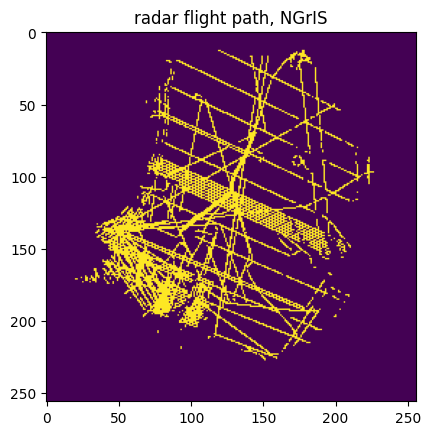

In [2]:
radar_mask = loadmat("../data/NGrIS/ensemble_data_pixelated/radar_mask.mat")['radar_mask']
radar_mask = (radar_mask == 1)

plt.imshow(radar_mask)
plt.title('radar flight path, NGrIS')

In [3]:
from shapely.geometry import Point
from shapely.geometry.polygon import Polygon

x = loadmat('../data/NGrIS/ensemble_data_pixelated/x_grid.mat')['grid_x_center']
y = loadmat('../data/NGrIS/ensemble_data_pixelated/y_grid.mat')['grid_y_center']
coor_xy = np.hstack((x.flatten()[:, np.newaxis], y.flatten()[:, np.newaxis]))

NW_boundary = loadmat('../data/NGrIS/boundary/NW_boundary_ordered.mat')['NW_boundary_ordered']
NO_boundary = loadmat('../data/NGrIS/boundary/NO_boundary_ordered.mat')['NO_boundary_ordered']
NE_boundary = loadmat('../data/NGrIS/boundary/NE_boundary_ordered.mat')['NE_boundary_ordered']

NW_polygon = Polygon(NW_boundary[:, 1:])
NO_polygon = Polygon(NO_boundary[:, 1:])
NE_polygon = Polygon(NE_boundary[:, 1:])

in_NW = np.full(len(coor_xy), np.nan)
in_NO = np.full(len(coor_xy), np.nan)
in_NE = np.full(len(coor_xy), np.nan)

for i in range(len(coor_xy)):
    pt = Point(coor_xy[i, :])
    in_NW[i] = NW_polygon.contains(pt)
    in_NO[i] = NO_polygon.contains(pt)
    in_NE[i] = NE_polygon.contains(pt)

in_NW = in_NW.reshape((256, 256))
in_NW = (in_NW == 1)

in_NO = in_NO.reshape((256, 256))
in_NO = (in_NO == 1)

in_NE = in_NE.reshape((256, 256))
in_NE = (in_NE == 1)


# plt.plot(NW_boundary[:, 1], NW_boundary[:, 2])

(np.float64(-676589.659026731),
 np.float64(689798.9338470697),
 np.float64(-772247.2774633017),
 np.float64(-1992283.7007416142))

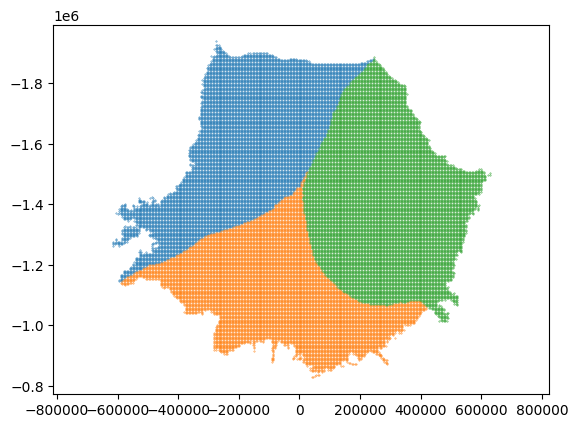

In [4]:
plt.scatter(x[in_NW], y[in_NW], s = 0.1)
plt.scatter(x[in_NO], y[in_NO], s = 0.1)
plt.scatter(x[in_NE], y[in_NE], s = 0.1)
plt.xlim(-8e5, 8e5)
plt.ylim(-0.8e6, -1.2e6)
plt.axis('equal')

In [5]:
# load simulation data
Em = loadmat("../data/NGrIS/ensemble_data_pixelated/enthalpy_avg_grid.mat")['enthalpy_avg_grid']
pmp = loadmat("../data/NGrIS/ensemble_data_pixelated/pmp_grid.mat")['pmp_grid']
radar_mask = loadmat("../data/NGrIS/ensemble_data_pixelated/radar_mask.mat")['radar_mask']
radar_mask = (radar_mask == 1)

Em = np.array(Em)
pmp = pmp[:, :, np.newaxis]
pmp = np.tile(pmp, (1, 1, Em.shape[2]))

# convert Em to attenu rate
Tm = ice.enthalpy_to_temperature(Em, Tpmp = pmp, istorch = False)

# convert Tm to attenu rate
attenu_fromEm = ice.temperature_to_atten_rate_ice(Tm)

non_convergence_idx = np.arange(attenu_fromEm.shape[2])[np.all(np.isnan(attenu_fromEm), axis = (0, 1))]
attenu_fromEm = np.delete(attenu_fromEm, non_convergence_idx, axis = 2)
# attenu_fromEm = np.moveaxis(attenu_fromEm, 2, 0) # sample, image_dimension, image_dimension

attenu_fromEm_mean = np.nanmean(attenu_fromEm)
attenu_fromEm_std = np.nanstd(attenu_fromEm)

# relaxationm to decrease magnitude of z-score, does not change shape of distributions
# better for training to avoid large magnitude z-score
# attenu_fromEm_std = 1

# attenu_fromEm_mean = np.tile(attenu_fromEm_mean, (1, 1, attenu_fromEm.shape[2]))
# attenu_fromEm_std = np.tile(attenu_fromEm_std, (1, 1, attenu_fromEm.shape[2]))
attenu_fromEm_standard = (attenu_fromEm - attenu_fromEm_mean) / attenu_fromEm_std

# transformer_attenu = sklearn.preprocessing.StandardScaler()

# Eb_standard = transformer_Eb.fit_transform(Eb.reshape(-1, 1))
# Eb_standard = Eb_standard.reshape(int(np.sqrt(np.shape(Eb_standard)[0]/Eb.shape[2])), int(np.sqrt(np.shape(Eb_standard)[0]/Eb.shape[2])), Eb.shape[2])

# transformer_attenu = sklearn.preprocessing.StandardScaler()
# attenu_fromEm_standard = transformer_attenu.fit_transform(attenu_fromEm.reshape(attenu_fromEm.shape[0], -1))
# attenu_fromEm_standard = attenu_fromEm_standard.reshape((attenu_fromEm_standard.shape[0], 256, 256))
# attenu_fromEm_standard = np.moveaxis(attenu_fromEm_standard, 0, 2)
# attenu_fromEm_standard = attenu_fromEm_standard.reshape(int(np.sqrt(np.shape(attenu_fromEm_standard)[0]/attenu_fromEm.shape[2])), int(np.sqrt(np.shape(attenu_fromEm_standard)[0]/attenu_fromEm.shape[2])), attenu_fromEm.shape[2])

# filter points not on radar flight path
# note: nan is filled with 0 for PCA
attenu_fromEm_standard[np.tile(radar_mask[:, :, np.newaxis], (1, 1, attenu_fromEm_standard.shape[2])) != 1] = 0
attenu_fromEm_standard = np.moveaxis(attenu_fromEm_standard, -1, 0)
attenu_fromEm_standard = attenu_fromEm_standard[:, np.newaxis, :, :]
attenu_fromEm_standard[np.isnan(attenu_fromEm_standard)] = 0
attenu_fromEm_standard = torch.tensor(attenu_fromEm_standard).float()

# saved standardized data and transformer
# joblib.dump(transformer_attenu, f'./saved_data/transformer_attenu.pkl')
np.savez('./saved_data/attenu_fromEm_standard.npz', attenu_fromEm_standard = attenu_fromEm_standard)

# Eb_standard = np.moveaxis(Eb_standard, -1, 0)
# Eb_standard = Eb_standard[:, np.newaxis, :, :]
# Eb_standard[np.isnan(Eb_standard)] = 0
# np.savez('Eb_standard.npz', Eb_standard = Eb_standard)
# Eb_standard = torch.tensor(Eb_standard).float()

/Users/leo/Documents/Glaciology/calibrated-prior/.venv/lib/python3.11/site-packages/numpy/lib/_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


Text(0, 0.5, '$N_a$ std')

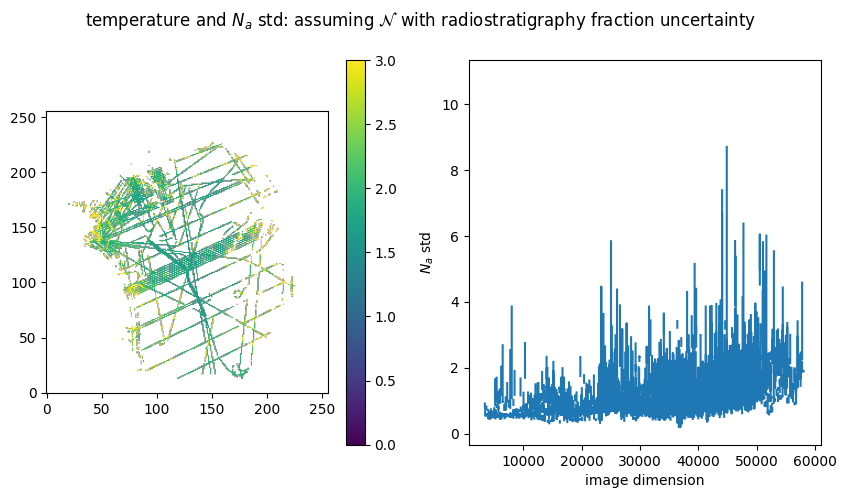

In [6]:
radar_temp_avg_samples_grid = loadmat('../data/NGrIS/ensemble_data_pixelated/radar_temp_avg_samples_grid.mat')['radar_temp_avg_samples_grid']
radar_temp_avg_samples_grid = radar_temp_avg_samples_grid[:, :, 0, :]

attenu_obs_samples = ice.temperature_to_atten_rate_ice(radar_temp_avg_samples_grid)

fig, ax = plt.subplots(1, 2, figsize = (10, 5))

fig.suptitle(rf'temperature and $N_a$ std: assuming $\mathcal{{N}}$ with radiostratigraphy fraction uncertainty')

im0 = ax[0].imshow(np.nanstd(radar_temp_avg_samples_grid, axis = 2), vmin = 0, vmax = 3)
ax[0].invert_yaxis()
plt.colorbar(im0)

ax[1].plot(np.nanstd(attenu_obs_samples, axis = 2).flatten())
ax[1].set_xlabel(rf"image dimension")
ax[1].set_ylabel(rf"$N_a$ std")

/var/folders/zz/9d0y_vp944zcnd6w_nl_3x6r0000gn/T/ipykernel_74278/1384079844.py:1: RuntimeWarning: Mean of empty slice
  attenu_fromEm_NW_mean = np.nanmean(attenu_fromEm, axis = 2)[in_NW & radar_mask]
/var/folders/zz/9d0y_vp944zcnd6w_nl_3x6r0000gn/T/ipykernel_74278/1384079844.py:2: RuntimeWarning: Mean of empty slice
  attenu_fromEm_NO_mean = np.nanmean(attenu_fromEm, axis = 2)[in_NO & radar_mask]
/var/folders/zz/9d0y_vp944zcnd6w_nl_3x6r0000gn/T/ipykernel_74278/1384079844.py:3: RuntimeWarning: Mean of empty slice
  attenu_fromEm_NE_mean = np.nanmean(attenu_fromEm, axis = 2)[in_NE & radar_mask]
/var/folders/zz/9d0y_vp944zcnd6w_nl_3x6r0000gn/T/ipykernel_74278/1384079844.py:8: RuntimeWarning: Mean of empty slice
  attenu_obs_samples_mean = np.nanmean(attenu_obs_samples, axis = 2)
/var/folders/zz/9d0y_vp944zcnd6w_nl_3x6r0000gn/T/ipykernel_74278/1384079844.py:21: RuntimeWarning: Mean of empty slice
  ax[1].hist(np.nanmean(attenu_fromEm, axis = 2)[radar_mask], bins = 200, alpha = 0.5, density

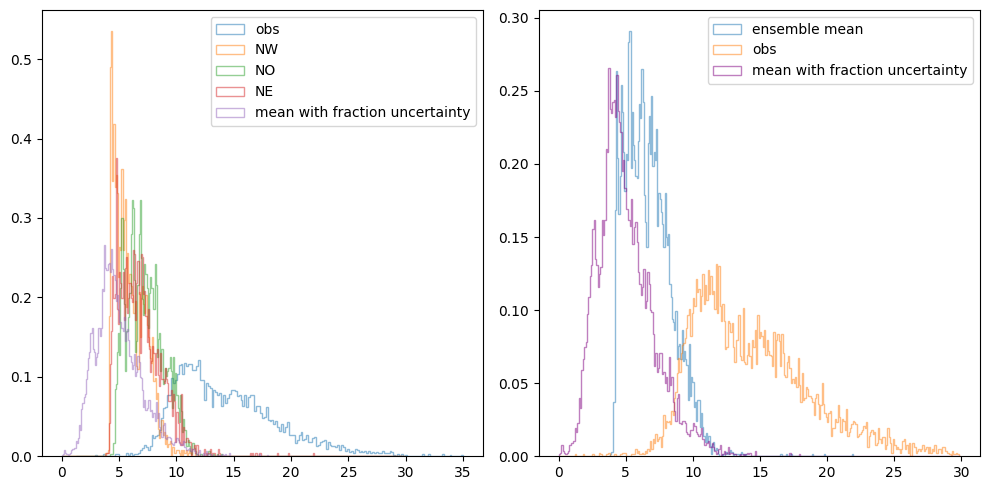

In [7]:
attenu_fromEm_NW_mean = np.nanmean(attenu_fromEm, axis = 2)[in_NW & radar_mask]
attenu_fromEm_NO_mean = np.nanmean(attenu_fromEm, axis = 2)[in_NO & radar_mask]
attenu_fromEm_NE_mean = np.nanmean(attenu_fromEm, axis = 2)[in_NE & radar_mask]

attenu_obs = loadmat('../data/NGrIS/ensemble_data_pixelated/radar_attenu_rate_mean_grid.mat')['radar_attenu_rate_mean_grid']

# this is the mean of samples generated from radiostratigraphy fraction uncertainty
attenu_obs_samples_mean = np.nanmean(attenu_obs_samples, axis = 2)

fig, ax = plt.subplots(1,2, figsize = (10, 5))
# plt.hist(attenu_fromEm_mean_NW, bins = 200, alpha = 0.5, density = True);

bins = np.arange(0, 30, 0.1)
ax[0].hist(attenu_obs[~np.isnan(attenu_obs)], bins = 200, alpha = 0.5, density = True, histtype='step', label = 'obs');
ax[0].hist(attenu_fromEm_NW_mean, bins = bins, alpha = 0.5, density = True,  histtype='step', label = 'NW');
ax[0].hist(attenu_fromEm_NO_mean, bins = bins, alpha = 0.5, density = True,  histtype='step', label = 'NO');
ax[0].hist(attenu_fromEm_NE_mean, bins = bins, alpha = 0.5, density = True,  histtype='step', label = 'NE');
ax[0].hist(attenu_obs_samples_mean.flatten(), bins = bins, alpha = 0.5, density = True,  histtype='step', label = 'mean with fraction uncertainty');
ax[0].legend()

ax[1].hist(np.nanmean(attenu_fromEm, axis = 2)[radar_mask], bins = 200, alpha = 0.5, density = True, histtype='step', label = 'ensemble mean');
ax[1].hist(attenu_obs.flatten(), bins = bins, alpha = 0.5, density = True, histtype='step', label = 'obs');
ax[1].hist(attenu_obs_samples_mean.flatten(), bins = bins, alpha = 0.5, density = True,  histtype='step', color = 'purple', label = 'mean with fraction uncertainty');
ax[1].legend()

fig.tight_layout()

/var/folders/zz/9d0y_vp944zcnd6w_nl_3x6r0000gn/T/ipykernel_74278/633787420.py:4: RuntimeWarning: Mean of empty slice
  ensemble_mean_mode = mode(np.round(np.nanmean(attenu_fromEm, axis = 2).flatten(), 1), nan_policy='omit').mode
/var/folders/zz/9d0y_vp944zcnd6w_nl_3x6r0000gn/T/ipykernel_74278/633787420.py:34: RuntimeWarning: Mean of empty slice
  ax[1].hist(np.nanmean(attenu_fromEm, axis = 2)[radar_mask], bins = 500, alpha = 0.5, density = True, histtype='step', label = 'ensemble mean');


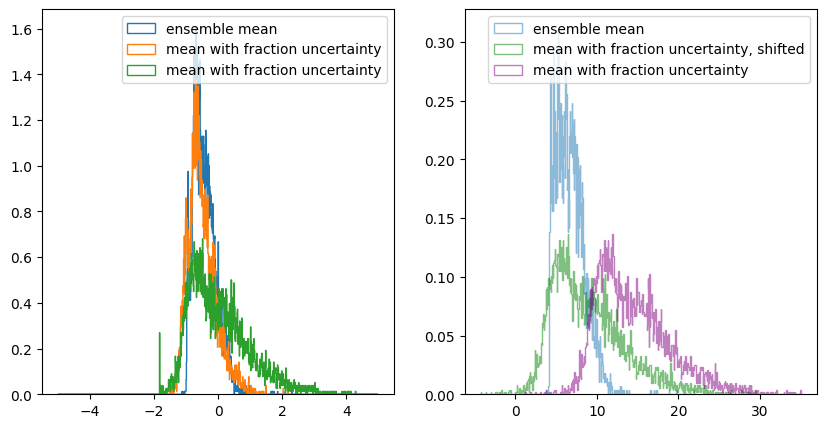

In [8]:
# attenu_obs_standard = transformer_attenu.transform(attenu_obs.reshape(1, -1))

from scipy.stats import mode
ensemble_mean_mode = mode(np.round(np.nanmean(attenu_fromEm, axis = 2).flatten(), 1), nan_policy='omit').mode
obs_samples_mode = mode(np.round(attenu_obs_samples_mean.flatten(), 1), nan_policy='omit').mode
obs_mode = mode(np.round(attenu_obs.flatten(), 1), nan_policy='omit').mode

attenu_obs_samples_mean_standard = (attenu_obs_samples_mean + (ensemble_mean_mode - obs_samples_mode) - attenu_fromEm_mean) / attenu_fromEm_std
attenu_obs_samples_mean_standard = attenu_obs_samples_mean_standard.flatten()

# temporary fix, aftering shifting by mode
attenu_obs_standard = attenu_obs + (ensemble_mean_mode - obs_mode)
attenu_obs_standard[attenu_obs_standard < 1e-2] = 1e-2
attenu_obs_standard = (attenu_obs_standard - attenu_fromEm_mean) / attenu_fromEm_std
attenu_obs_standard = attenu_obs_standard.flatten()


# plt.hist(attenu_obs_samples_mean_standard.flatten(), alpha = 0.5)

# attenu_obs_standard[np.isnan(attenu_obs_standard)] = 0

fig, ax = plt.subplots(1,2, figsize = (10, 5))
# plt.hist(attenu_fromEm_mean_NW, bins = 200, alpha = 0.5, density = True);


bins = np.arange(-5, 5, 0.01)
ax[0].hist(attenu_fromEm_standard[0, 0, :, :][radar_mask].flatten(), bins = bins, density = True, histtype='step', label = 'ensemble mean');
ax[0].hist(attenu_obs_samples_mean_standard[~np.isnan(attenu_obs_samples_mean_standard) & radar_mask.flatten()], bins = bins, density = True, histtype='step', label = 'mean with fraction uncertainty');
ax[0].hist(attenu_obs_standard[radar_mask.flatten()].flatten(), bins = bins, density = True, histtype='step', label = 'mean with fraction uncertainty');

ax[0].legend()

bins = np.arange(0, 30, 0.01)
ax[1].hist(np.nanmean(attenu_fromEm, axis = 2)[radar_mask], bins = 500, alpha = 0.5, density = True, histtype='step', label = 'ensemble mean');
ax[1].hist((attenu_obs[radar_mask]).flatten() + (ensemble_mean_mode - obs_mode), bins = 500, alpha = 0.5, density = True,  histtype='step', color = 'green', label = 'mean with fraction uncertainty, shifted');
ax[1].hist((attenu_obs[radar_mask]).flatten(), bins = 500, alpha = 0.5, density = True, histtype='step', color = 'purple', label = 'mean with fraction uncertainty');

ax[1].legend()

attenu_obs_samples_mean_standard[np.isnan(attenu_obs_samples_mean_standard)] = 0
attenu_obs_standard[np.isnan(attenu_obs_standard)] = 0

/var/folders/zz/9d0y_vp944zcnd6w_nl_3x6r0000gn/T/ipykernel_74278/4039714012.py:5: RuntimeWarning: Mean of empty slice
  standard_1 = (attenu_fromEm - np.tile(np.nanmean(attenu_fromEm, axis = 2)[:, :, np.newaxis], (1, 1, 209))) / np.tile(np.nanstd(attenu_fromEm, axis = 2)[:, :, np.newaxis], (1, 1, 209))


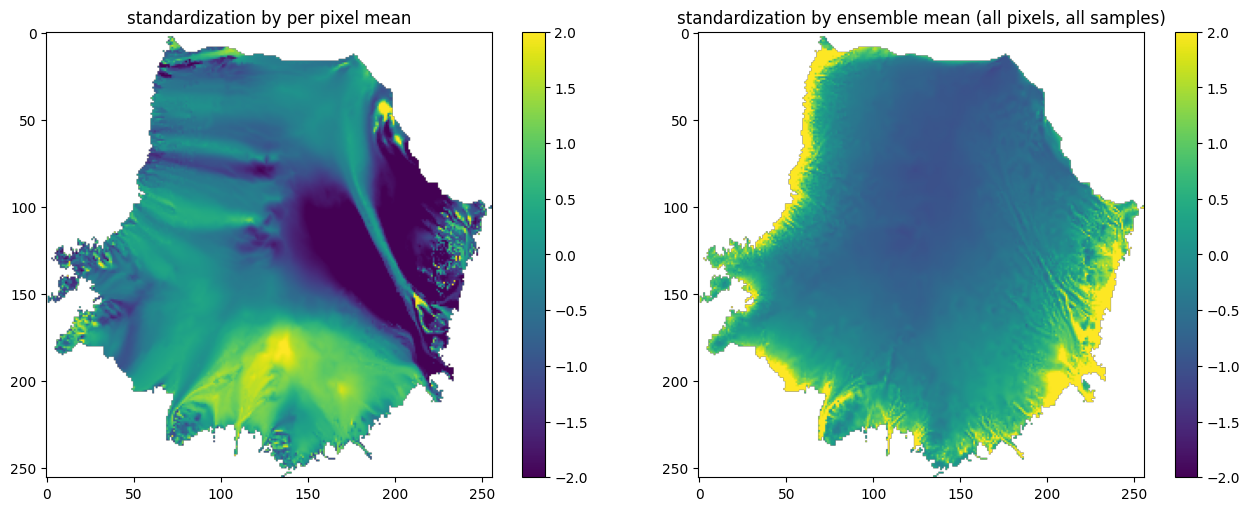

In [133]:
# standardization method comparison

fig, ax = plt.subplots(1,2, figsize = (13, 5), layout="constrained")

standard_1 = (attenu_fromEm - np.tile(np.nanmean(attenu_fromEm, axis = 2)[:, :, np.newaxis], (1, 1, 209))) / np.tile(np.nanstd(attenu_fromEm, axis = 2)[:, :, np.newaxis], (1, 1, 209))
standard_2 = (attenu_fromEm - np.nanmean(attenu_fromEm)) / np.nanstd(attenu_fromEm)

vmin = -2
vmax = 2

im0 = ax[0].imshow(standard_1[:, :, 3], vmin = vmin, vmax = vmax)
ax[0].set_title("standardization by per pixel mean")

im1 = ax[1].imshow(standard_2[:, :, 3], vmin = vmin, vmax = vmax)
ax[1].set_title("standardization by ensemble mean (all pixels, all samples)")

plt.colorbar(im0)
plt.colorbar(im1)

## PCA

In [10]:
# # detect if there are repeated samples in ensemble data
# unique_count = []
# for i in range(attenu_latent.shape[1]):
#     unique_count.append(torch.unique(attenu_latent[:, i]).shape[0])

# load data: attenuation rate in PCA latent space
#num_epochs = 50

# attenu_pca = joblib.load('./saved_data/attenu_pca.pkl')
attenu_pca = sklearn.decomposition.PCA(n_components = 32)
attenu_pca.fit(attenu_fromEm_standard[:, 0, :, :].reshape((-1, attenu_fromEm_standard.shape[2] ** 2)))

# joblib.dump(attenu_pca, './saved_data/attenu_pca.pkl')

attenu_latent = attenu_pca.transform(attenu_fromEm_standard[:, 0, :, :].reshape((-1, attenu_fromEm_standard.shape[2] ** 2)))
attenu_latent = torch.tensor(attenu_latent).float()

In [11]:
batch_size = 16
# train val test split
attenu_latent_dataset = TensorDataset(attenu_latent, attenu_latent)
#attenu_latent_dataset = TensorDataset(attenu_latent_standard, attenu_latent_standard)

train_size = (int(0.7 * len(attenu_latent_dataset)) // batch_size) * batch_size
val_size = int((len(attenu_latent_dataset) - train_size)/2)
test_size = int(len(attenu_latent_dataset) - train_size - val_size)

generator = torch.Generator().manual_seed(42)
attenu_latent_train_dataset, attenu_latent_val_dataset, attenu_latent_test_dataset = random_split(attenu_latent_dataset, [train_size, val_size, test_size], generator=generator)

attenu_latent_train_dataloader = DataLoader(attenu_latent_train_dataset, batch_size = batch_size, shuffle = 1)
attenu_latent_val_dataloader = DataLoader(attenu_latent_val_dataset, batch_size = batch_size, shuffle = 1)
attenu_latent_test_dataloader = DataLoader(attenu_latent_test_dataset, batch_size = batch_size, shuffle = 1)

print(f"train size: {train_size}, val_size: {val_size}, test_size: {test_size}")

train size: 144, val_size: 32, test_size: 33


Text(0.5, 1.0, 'cumulative explained variance')

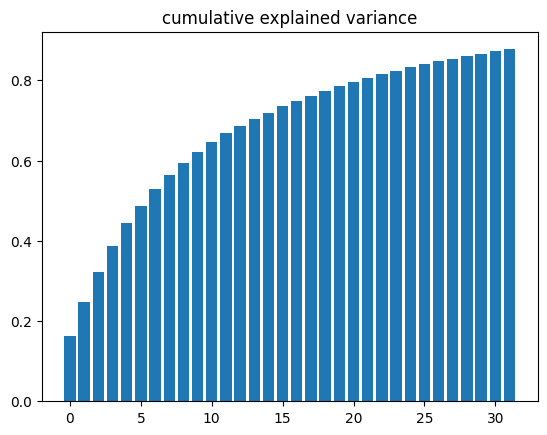

In [12]:
plt.bar(np.arange(np.cumsum(attenu_pca.explained_variance_ratio_).shape[0]), height = np.cumsum(attenu_pca.explained_variance_ratio_))
plt.title("cumulative explained variance")

Text(0.5, 0, 'latent space')

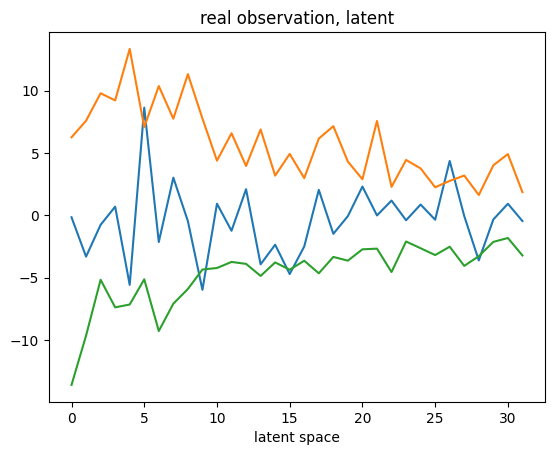

In [13]:
attenu_obs_samples_mean_latent = attenu_pca.transform(attenu_obs_samples_mean_standard.reshape(1, -1))
plt.plot(attenu_obs_samples_mean_latent.flatten(), label = 'obs')
plt.plot(torch.max(attenu_latent, axis = 0)[0], label = 'ensemble max')
plt.plot(torch.min(attenu_latent, axis = 0)[0], label = 'ensemble min')
plt.title("real observation, latent")
plt.xlabel("latent space")

# Architecture (MaskedAffineAutoregressive)

In [14]:
# # Set up model_nf
# # in_features = int(attenu_latent.shape[1]/2)

# # Define list of flows
# num_layers = 2
# flows = []
# for i in range(num_layers):
#     flows.append(nf.flows.MaskedAffineAutoregressive(32, 64))

# # base distribution is a Gaussian with num of dimension same as training data
# base = nf.distributions.base.DiagGaussian(32)

# # Construct flow model_nf
# model_nf = nf.NormalizingFlow(base, flows)

# model_nf

# Architecture (normflows, real NVP)

In [15]:
# Set up model_nf
in_features = int(attenu_latent.shape[1]/2)

# Define list of flows
num_layers = 4
flows = []
for i in range(num_layers):
    param_map = nf.nets.MLP([in_features, 64, 256, 64, in_features * 2], init_zeros=True, leaky = 0.01)
    # Add flow layer
    flows.append(nf.flows.AffineCouplingBlock(param_map))
    # Swap dimensions
    flows.append(nf.flows.Permute(in_features * 2, mode='shuffle'))

# base distribution is a Gaussian with num of dimension same as training data
base = nf.distributions.base.DiagGaussian(in_features * 2)

# Construct flow model_nf
model_nf = nf.NormalizingFlow(base, flows)

model_nf

NormalizingFlow(
  (q0): DiagGaussian()
  (flows): ModuleList(
    (0): AffineCouplingBlock(
      (flows): ModuleList(
        (0): Split()
        (1): AffineCoupling(
          (param_map): MLP(
            (net): Sequential(
              (0): Linear(in_features=16, out_features=64, bias=True)
              (1): LeakyReLU(negative_slope=0.01)
              (2): Linear(in_features=64, out_features=256, bias=True)
              (3): LeakyReLU(negative_slope=0.01)
              (4): Linear(in_features=256, out_features=64, bias=True)
              (5): LeakyReLU(negative_slope=0.01)
              (6): Linear(in_features=64, out_features=32, bias=True)
            )
          )
        )
        (2): Merge()
      )
    )
    (1): Permute()
    (2): AffineCouplingBlock(
      (flows): ModuleList(
        (0): Split()
        (1): AffineCoupling(
          (param_map): MLP(
            (net): Sequential(
              (0): Linear(in_features=16, out_features=64, bias=True)
             

# Training

In [16]:
# using linear regression to prevent overfitting
window_size = 100

reg = sklearn.linear_model.LinearRegression()
window = np.arange(window_size).reshape(-1, 1)

# Train model_nf
max_epoch = 1000
early_stopping_threshold = 5e-3

epoch_loss = np.array([])
epoch_loss_val = np.array([])

#optimizer = torch.optim.Adam(model_nf.parameters(), lr=1e-5, weight_decay=1e-5)
optimizer = torch.optim.AdamW(model_nf.parameters(), lr=1e-5)
model_nf.train()

try:
    for epoch in range(max_epoch):
        optimizer.zero_grad()

        start = torch.Event(enable_timing=True)
        end = torch.Event(enable_timing=True)
        start.record()

        running_loss = 0.0
        running_loss_val = 0.0

        for train_batch, _ in attenu_latent_train_dataloader:
            # Compute loss
            loss = model_nf.forward_kld(train_batch)
            
            # Do backprop and optimizer step
            if ~(torch.isnan(loss) | torch.isinf(loss)):
                loss.backward()
                optimizer.step()
                running_loss += loss.item() * train_batch.size(0)

        for val_batch, _ in attenu_latent_val_dataloader:
            # Compute loss
            val_loss = model_nf.forward_kld(val_batch)

            # Do backprop and optimizer step
            if ~(torch.isnan(val_loss) | torch.isinf(val_loss)):
                val_loss.backward()
                optimizer.step()
                running_loss_val += val_loss.item() * val_batch.size(0)
        
        epoch_loss = np.append(epoch_loss, running_loss / len(attenu_latent_train_dataloader.dataset))
        epoch_loss_val = np.append(epoch_loss_val, running_loss_val / len(attenu_latent_val_dataloader.dataset))

        if epoch >= window.shape[0]:
            #print(epoch_loss[-window_size:])
            #print(epoch_loss_val[-window_size:])
            reg.fit(window, epoch_loss[-window_size:])
            epoch_loss_slope = reg.coef_


            reg.fit(window, epoch_loss_val[-window_size:])
            epoch_loss_val_slope = reg.coef_
            
            print(f"Epoch validation loss slope: {epoch_loss_val_slope}")
            print(f"Epoch loss slope: {epoch_loss_slope}")

            if (epoch_loss_slope > -early_stopping_threshold) or (epoch_loss_val_slope > -early_stopping_threshold):
                print("Early stopping")
                break

        end.record()
        if torch.cuda.is_available():
            torch.cuda.synchronize()
        print(f"Epoch [{epoch + 1}/{max_epoch}], loss: {epoch_loss[epoch]:.4f}, validation loss: {epoch_loss_val[epoch]:.4f}, time elapsed = {start.elapsed_time(end)/1000:.2f} s")
        
    torch.save(model_nf.state_dict(), f'./saved_data/realNVP.pth')
    np.savez(f'./saved_data/realNVP_loss.npz',epoch_loss = epoch_loss, epoch_loss_val = epoch_loss_val) 

except KeyboardInterrupt:
    torch.save(model_nf.state_dict(), f'./saved_data/realNVP.pth')
    np.savez(f'./saved_data/realNVP_loss.npz',epoch_loss = epoch_loss, epoch_loss_val = epoch_loss_val)


Epoch [1/1000], loss: 63.9550, validation loss: 63.6091, time elapsed = 0.01 s
Epoch [2/1000], loss: 63.8750, validation loss: 63.5638, time elapsed = 0.01 s
Epoch [3/1000], loss: 63.8046, validation loss: 63.5115, time elapsed = 0.01 s
Epoch [4/1000], loss: 63.7102, validation loss: 63.4541, time elapsed = 0.01 s
Epoch [5/1000], loss: 63.6121, validation loss: 63.3932, time elapsed = 0.01 s
Epoch [6/1000], loss: 63.5113, validation loss: 63.3239, time elapsed = 0.01 s
Epoch [7/1000], loss: 63.3814, validation loss: 63.2458, time elapsed = 0.01 s
Epoch [8/1000], loss: 63.2571, validation loss: 63.1670, time elapsed = 0.01 s
Epoch [9/1000], loss: 63.1148, validation loss: 63.0812, time elapsed = 0.01 s
Epoch [10/1000], loss: 62.9659, validation loss: 62.9939, time elapsed = 0.01 s
Epoch [11/1000], loss: 62.8246, validation loss: 62.8903, time elapsed = 0.01 s
Epoch [12/1000], loss: 62.6531, validation loss: 62.7787, time elapsed = 0.01 s
Epoch [13/1000], loss: 62.4536, validation loss: 

Text(0.5, 0.98, 'KL-divergence = -log(mean(prob))')

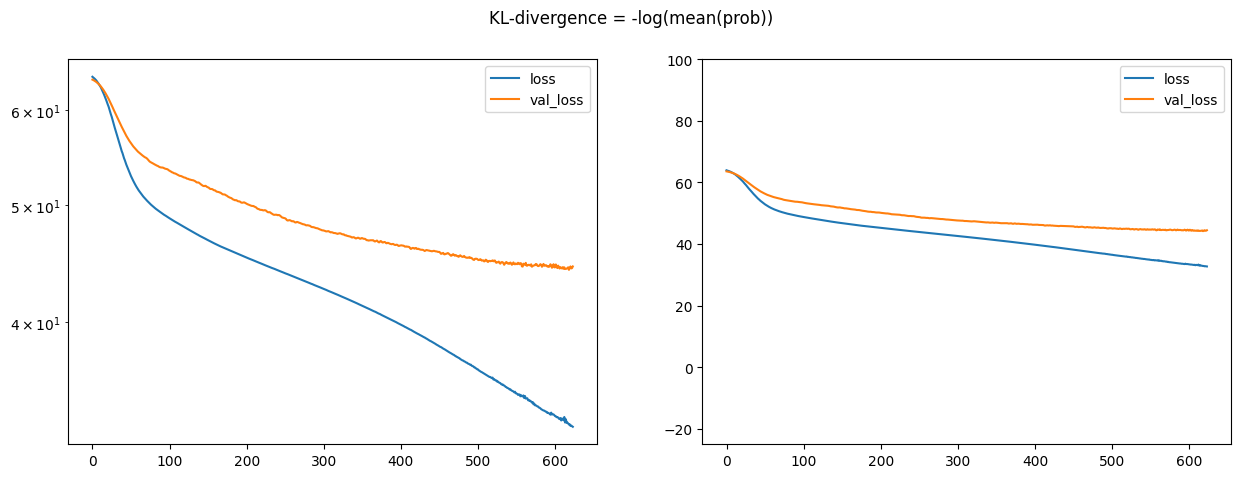

<Figure size 1000x500 with 0 Axes>

In [17]:
# Plot loss
# epoch_loss = np.load('../notebooks/saved_data/realNVP_loss_32_5e-05_128_64_1.npz')['epoch_loss']
# epoch_loss_val = np.load('../notebooks/saved_data/realNVP_loss_32_5e-05_128_64_1.npz')['epoch_loss_val']

fig, ax = plt.subplots(1,2, figsize = (15, 5))
plt.figure(figsize=(10, 5))
ax[0].plot(epoch_loss, label='loss')
ax[0].plot(epoch_loss_val, label='val_loss')
ax[0].legend()
ax[0].set_yscale('log')

ax[1].plot(epoch_loss, label='loss')
ax[1].plot(epoch_loss_val, label='val_loss')
ax[1].legend()
ax[1].set_ylim(-25, 100)

fig.suptitle('KL-divergence = -log(mean(prob))')

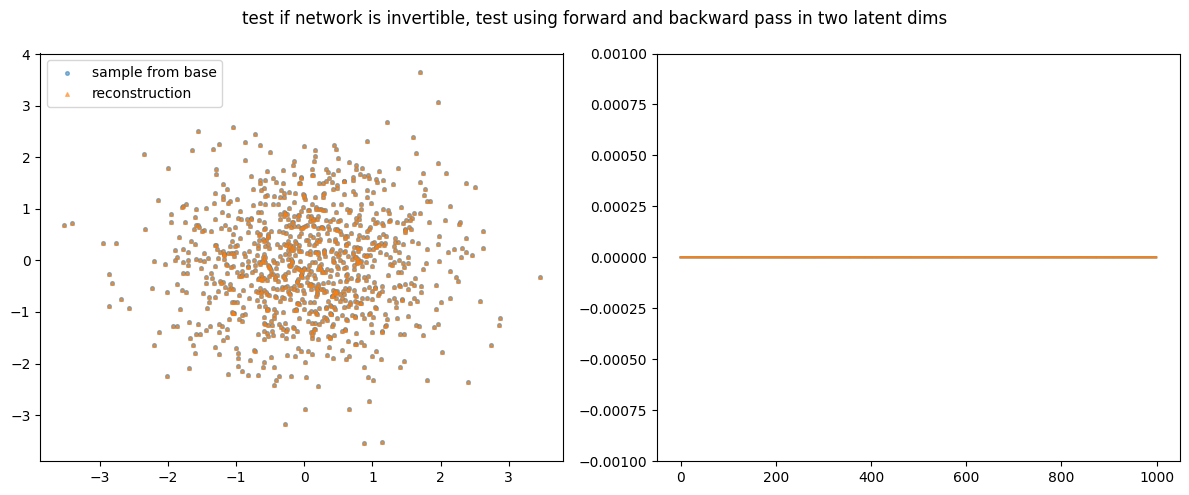

In [123]:
# model_nf.load_state_dict(torch.load('../notebooks/saved_data/realNVP_32_5e-05_128_64_2.pth', weights_only=True))
model_nf.eval()

x0 = base.sample(1000)
x1_from_x0 = model_nf.forward(x0)
x1 = model_nf.sample(1000)[0]
x0_from_x1_from_x0 = model_nf.inverse(x1_from_x0)

x0 = x0.detach().numpy()
x1 = x1.detach().numpy()
x1_from_x0 = x1_from_x0.detach().numpy()
x0_from_x1_from_x0 = x0_from_x1_from_x0.detach().numpy()

fig, ax = plt.subplots(1, 2, figsize = (12, 5))
ax[0].scatter(x0[:, 0], x0[:, 1], alpha = 0.5, label = 'sample from base', s = 7)
#plt.scatter(x1[:, 0], x1[:, 1])
#plt.scatter(x1_from_x0[:, 0], x1_from_x0[:, 1])
ax[0].scatter(x0_from_x1_from_x0[:, 0], x0_from_x1_from_x0[:, 1], alpha = 0.5, label = 'reconstruction', marker = '^', s = 7)
ax[0].legend()


ax[1].plot(x0_from_x1_from_x0[:, 0] - x0[:, 0])
ax[1].plot(x0_from_x1_from_x0[:, 1] - x0[:, 1])
ax[1].set_ylim(-1e-3, 1e-3)

fig.suptitle("test if network is invertible, test using forward and backward pass in two latent dims")
fig.tight_layout()

# Sampling

Text(0.5, 0.98, 'comparing samples drawn from NF prior and ensemble')

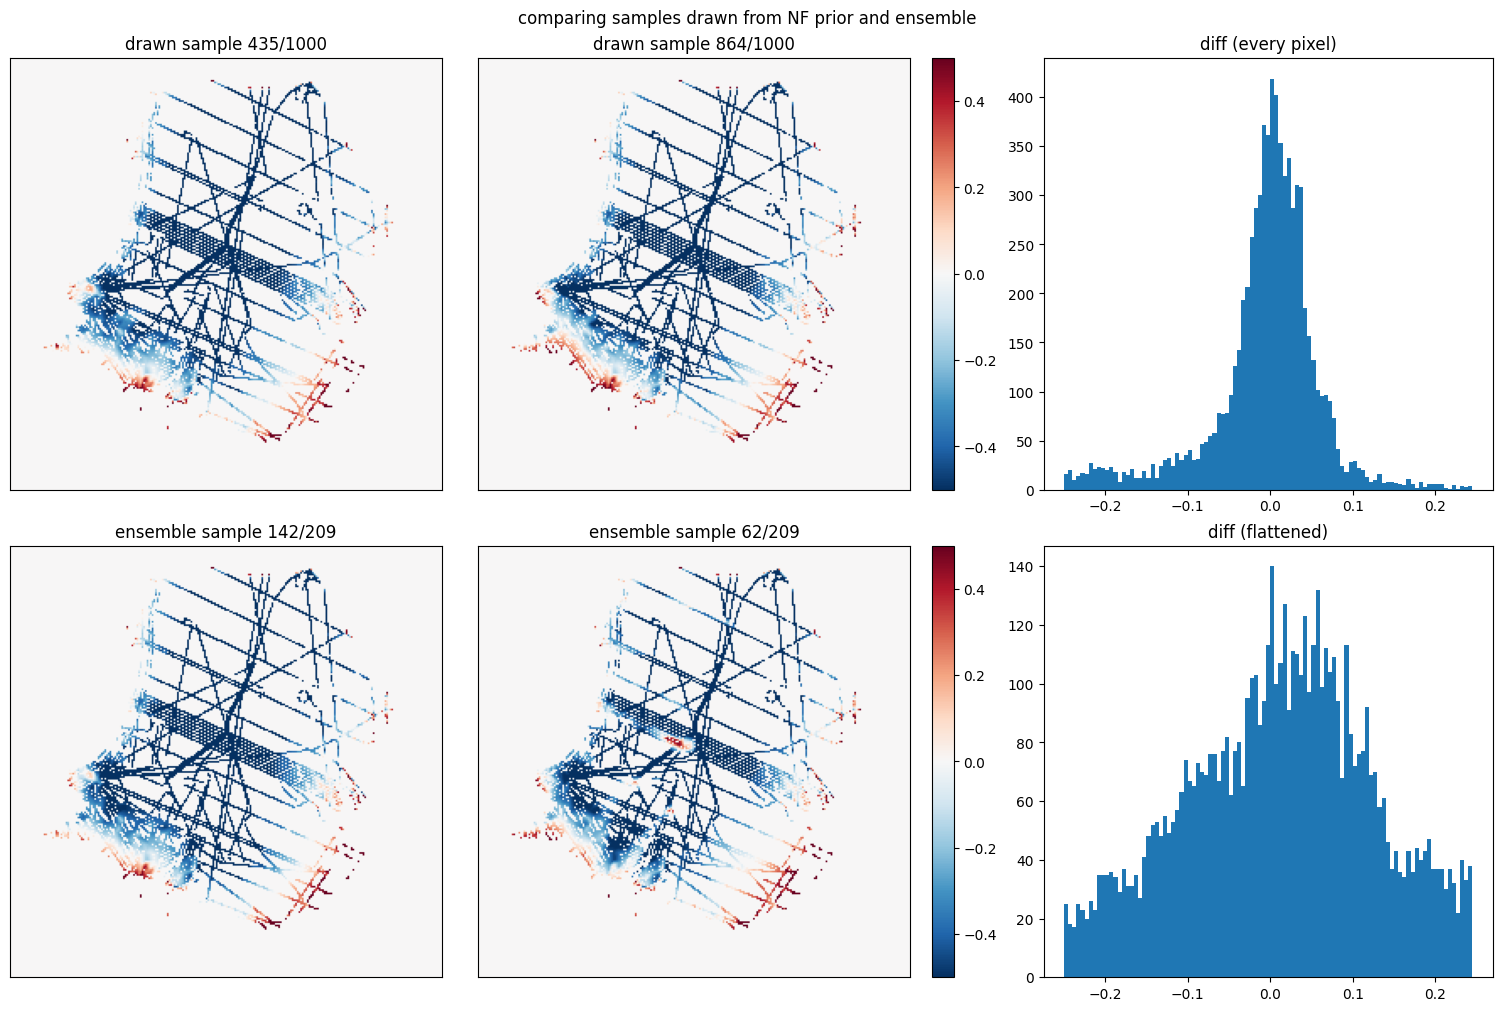

In [119]:
#attenu_pca = joblib.load('../testing/attenu_pca2026-06-12 15:13:52.857122.pkl')

attenu_samples_nf_latent, attenu_samples_log_prob = model_nf.sample(1000)
attenu_samples_nf_latent = attenu_samples_nf_latent.reshape((attenu_samples_nf_latent.shape[0], -1))
attenu_samples_nf_latent = attenu_samples_nf_latent[(~torch.isnan(attenu_samples_log_prob)) & (~torch.isinf(attenu_samples_log_prob)), :]
attenu_samples_nf_latent[attenu_samples_nf_latent == torch.nan] = 0
attenu_samples_nf_latent[attenu_samples_nf_latent == torch.inf] = 0
attenu_samples_nf_latent[attenu_samples_nf_latent == -torch.inf] = 0
# attenu_samples_nf_latent[torch.abs(attenu_samples_nf_latent) > 1e2] = 0
attenu_samples_nf = attenu_pca.inverse_transform(attenu_samples_nf_latent.detach().numpy())
attenu_samples_nf = attenu_samples_nf.reshape((attenu_samples_nf_latent.shape[0], 256, 256))

fig, ax = plt.subplots(2,3, figsize = (15, 10), layout="constrained")

vmin = -0.5
vmax = 0.5

rng = np.random.default_rng()
idx = rng.choice(attenu_samples_nf.shape[0], size=2, replace=False)

ax[0, 0].imshow(attenu_samples_nf[idx[0], :, :], vmin = vmin, vmax = vmax, cmap = 'RdBu_r')
ax[0, 0].set_title(f"drawn sample {idx[0]}/{attenu_samples_nf.shape[0]}")
ax[0, 0].set_xticks([])
ax[0, 0].set_yticks([])

im01 = ax[0, 1].imshow(attenu_samples_nf[idx[1], :, :], vmin = vmin, vmax = vmax, cmap = 'RdBu_r')
ax[0, 1].set_title(f"drawn sample {idx[1]}/{attenu_samples_nf.shape[0]}")
ax[0, 1].set_xticks([])
ax[0, 1].set_yticks([])
plt.colorbar(im01)

bins = np.arange(-0.25, 0.25, 0.005)

ax[0, 2].hist((attenu_samples_nf[idx[0], :, :] - attenu_samples_nf[idx[1], :, :])[radar_mask].flatten(), bins = bins)
ax[0, 2].set_title("diff (every pixel)")
# ax[2].xaxis.set_visible(False)





# ensemble samples
attenu_samples_ensemble = attenu_pca.inverse_transform(attenu_latent.detach().numpy().reshape(attenu_latent.shape[0], -1))
attenu_samples_ensemble = attenu_samples_ensemble.reshape((attenu_samples_ensemble.shape[0], 256, 256))

vmin = -0.5
vmax = 0.5

rng = np.random.default_rng()
idx = rng.choice(attenu_samples_ensemble.shape[0], size=2, replace=False)

ax[1, 0].imshow(attenu_samples_ensemble[idx[0], :, :], vmin = vmin, vmax = vmax, cmap = 'RdBu_r')
ax[1, 0].set_title(f"ensemble sample {idx[0]}/{attenu_samples_ensemble.shape[0]}")
ax[1, 0].set_xticks([])
ax[1, 0].set_yticks([])

im11 = ax[1, 1].imshow(attenu_samples_ensemble[idx[1], :, :], vmin = vmin, vmax = vmax, cmap = 'RdBu_r')
ax[1, 1].set_title(f"ensemble sample {idx[1]}/{attenu_samples_ensemble.shape[0]}")
ax[1, 1].set_xticks([])
ax[1, 1].set_yticks([])
plt.colorbar(im11)

ax[1, 2].hist((attenu_samples_ensemble[idx[0], :, :] - attenu_samples_ensemble[idx[1], :, :])[radar_mask].flatten(), bins = bins)
ax[1, 2].set_title("diff (flattened)")

fig.suptitle("comparing samples drawn from NF prior and ensemble")

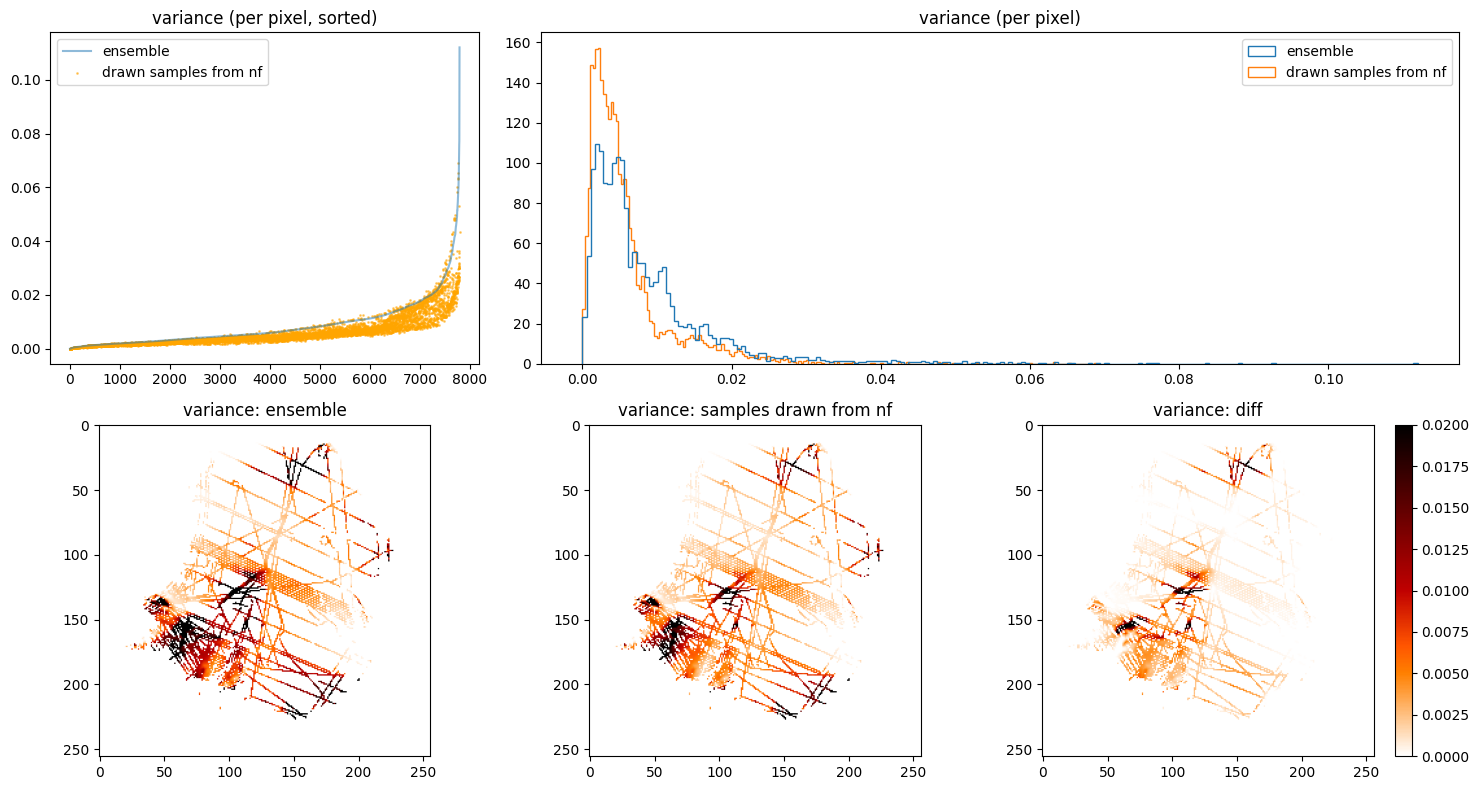

In [81]:
fig, ax = plt.subplot_mosaic([['A', 'B', 'B'],
                              ['C', 'D', 'E']],
                             figsize = (15, 8))

var_attenu_ensemble = np.var(attenu_samples_ensemble, axis = 0)
var_attenu_nf = np.var(attenu_samples_nf, axis = 0)
sort_idx = np.argsort(var_attenu_ensemble[radar_mask].flatten())

ax['A'].plot(var_attenu_ensemble[radar_mask].flatten()[sort_idx], label = 'ensemble', alpha = 0.5, zorder = 3)
ax['A'].scatter(np.arange(0, var_attenu_nf[radar_mask].flatten().shape[0], 1), var_attenu_nf[radar_mask].flatten()[sort_idx], label = 'drawn samples from nf', alpha = 0.5, s = 1, c = 'orange')
ax['A'].set_title("variance (per pixel, sorted)")
ax['A'].legend()

bins = np.arange(0, 1, 0.05)
ax['B'].hist(var_attenu_ensemble[radar_mask].flatten(), label = 'ensemble', zorder = 3, bins = 200, density = True, histtype='step')
ax['B'].hist(var_attenu_nf[radar_mask].flatten(), label = 'drawn samples from nf', bins = 200, density = True, histtype='step')
ax['B'].set_title("variance (per pixel)")
ax['B'].legend()

vmin = 0
vmax = 0.02

im0 = ax['C'].imshow(var_attenu_ensemble, vmin = vmin, vmax = vmax, cmap = 'gist_heat_r')
ax['C'].set_title(f"variance: ensemble")
# ax['C'].set_axis_off()
ax['C'].set_box_aspect(1) 

im1 = ax['D'].imshow(var_attenu_nf, vmin = vmin, vmax = vmax, cmap = 'gist_heat_r')
ax['D'].set_title(f"variance: samples drawn from nf")
# ax['D'].set_axis_off()
ax['D'].set_box_aspect(1) 

im2 = ax['E'].imshow(var_attenu_ensemble - var_attenu_nf, vmin = vmin, vmax = vmax, cmap = 'gist_heat_r')
ax['E'].set_title(f"variance: diff")
# ax['E'].set_axis_off()
ax['E'].set_box_aspect(1) 
plt.colorbar(im2)

fig.tight_layout()


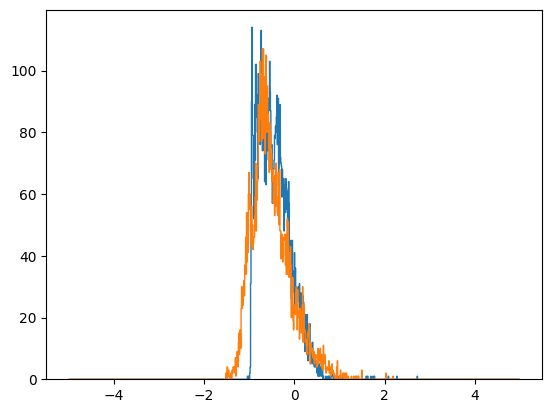

In [22]:
attenu_samples_nf_mean = np.mean(attenu_samples_nf, axis = 0)

bins = np.arange(-5, 5, 0.01)

plt.hist(attenu_samples_nf_mean[radar_mask].flatten(), bins = bins, histtype='step');
plt.hist(attenu_obs_samples_mean_standard[radar_mask.flatten()], bins = bins, histtype='step');

## Verify Autograd

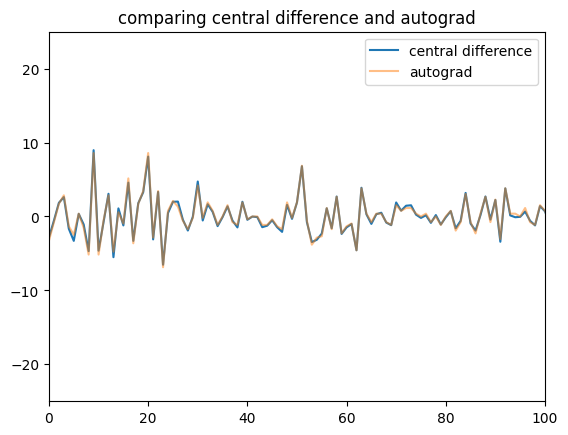

In [23]:
# z = base.sample(1)
# log_prob_z = base.log_prob(z)
# x, log_det_z_to_x = model_nf.forward_and_log_det(z)
# z_1, log_det_x_to_z = model_nf.inverse_and_log_det(x)
# x = model_nf.forward(z)
# log_prob_x = model_nf.log_prob(x)

# # note: log det have opposite sign as defined in this package
# # p(x) = p(z) + log(det(Jacobian(f(z->x)))) = p(z) - (log det output by model_nf.forward_and_log_det(z))
# log_det_z_to_x = -log_det_z_to_x
# log_det_x_to_z = -log_det_x_to_z

# autograd

z = base.sample(10)
log_prob_z = base.log_prob(z)
#x, log_det_z_to_x = model_nf.forward_and_log_det(z)
#z_1, log_det_x_to_z = model_nf.inverse_and_log_det(x)
x = model_nf.forward(z)
log_prob_x = model_nf.log_prob(x)

grad_autograd = torch.full(x.shape, float('nan'))

for i in range(len(log_prob_x)):
    grad_autograd[i, :] = torch.autograd.grad(log_prob_x[i], x, retain_graph= True)[0][i, :]

# central diff
grad_fd = torch.zeros(x.shape)

#step_sizes = float(10) ** (torch.arange(-7, -1, 0.1))
#diff_central = []
#diff_logp1_central = []

step = 5e-6

for i in range(grad_fd.shape[0]):
    for j in range(grad_fd.shape[1]):

        x_perturb_positive = x.clone().detach()
        x_perturb_positive = x_perturb_positive[i:i+1, :]
        x_perturb_positive[0,j] += step

        x_perturb_negative = x.clone().detach()
        x_perturb_negative = x_perturb_negative[i:i+1, :]
        x_perturb_negative[0,j] -= step

        log_prob_x_perturb_positive = model_nf.log_prob(x_perturb_positive)
        log_prob_x_perturb_negative = model_nf.log_prob(x_perturb_negative)

        diff_central = ((log_prob_x_perturb_positive - log_prob_x_perturb_negative)/(step * 2))
        #diff_central = ((log_p1_sample_perturb_positive - log_p1[i])/(step))
        grad_fd[i,j] = diff_central

grad_fd = grad_fd.detach().numpy()

plt.plot(grad_autograd.flatten(), label = 'central difference')
plt.plot(grad_fd.flatten(), alpha = 0.5, label = 'autograd')
plt.xlim((0, 100))
plt.ylim((-25, 25))
plt.title("comparing central difference and autograd")
plt.legend()

# HMC

In [24]:
log_posterior = torch.empty(4)
log_posterior

tensor([0., 0., 0., 0.])

In [25]:
model_nf.sample(4)[0].detach()

tensor([[ 5.0792e+00,  1.3216e+00,  1.4875e+00,  1.9286e+00,  2.7427e+00,
         -2.0137e+00,  1.6775e+00, -1.8473e+00,  3.4834e-01,  1.1335e+00,
         -1.0964e+00,  1.0859e+00, -3.1452e-01,  5.0996e-01,  1.3746e+00,
          4.3567e-01,  2.7482e-01, -3.9371e-01, -6.2340e-02,  7.6760e-02,
         -2.8600e-01, -4.7069e-01, -6.1927e-02,  4.1395e-01,  1.6625e+00,
          1.0646e-01,  5.8208e-02,  1.5471e-02, -6.0219e-01,  2.7082e-01,
         -1.4030e-01, -2.7089e-01],
        [ 5.1444e-01,  1.7566e+00, -4.1332e-01,  5.2157e-01, -1.0032e+00,
          1.8249e+00, -1.1610e+00,  6.8470e-01, -9.8889e-01, -7.8622e-01,
          1.6772e+00,  1.3478e-03, -1.0431e+00, -7.5539e-01, -2.6235e-01,
          1.8548e-01,  6.0134e-01, -9.2980e-01,  5.3940e-01, -8.9764e-02,
          1.6391e+00, -4.3004e-01,  2.6044e-01,  7.8920e-01,  7.5799e-01,
          1.2401e+00, -8.0723e-01,  5.4288e-01, -1.0113e+00, -5.0650e-01,
          2.4903e-01,  7.1583e-01],
        [-2.4410e+00, -2.8123e-02, -1.79

In [ ]:
import pyro
from pyro.infer.mcmc import MCMC, HMC, NUTS
import hamiltonianMC_nf

custom_potential = hamiltonianMC_nf.custom_potential(model_nf, attenu_pca, attenu_obs_standard, verbose = False)

log_posterior_complied = torch.compile(custom_potential.log_posterior)

mcmc_kernel = NUTS(potential_fn = custom_potential.log_posterior)

num_chains = 4
num_samples = 100 # samples per chain

mcmc = MCMC(mcmc_kernel, num_samples=num_samples, warmup_steps=1000, num_chains = num_chains,
                         initial_params={"x": model_nf.sample(num_chains)[0].detach().unsqueeze(1)})
mcmc.run()
# attenu_samples_hmc_latent[i, :] = mcmc.get_samples()['x'][0][0]

attenu_samples_hmc_latent = mcmc.get_samples()['x']
attenu_samples_hmc_latent = attenu_samples_hmc_latent[:, 0, :]
torch.save(attenu_samples_hmc_latent, './saved_data/attenu_samples_hmc_latent.pt')

Warmup [1]:   0%|          | 0/1100 [00:00, ?it/s]

Warmup [2]:   0%|          | 0/1100 [00:00, ?it/s]

Warmup [3]:   0%|          | 0/1100 [00:00, ?it/s]

Warmup [4]:   0%|          | 0/1100 [00:00, ?it/s]

(0.0, 1.2)

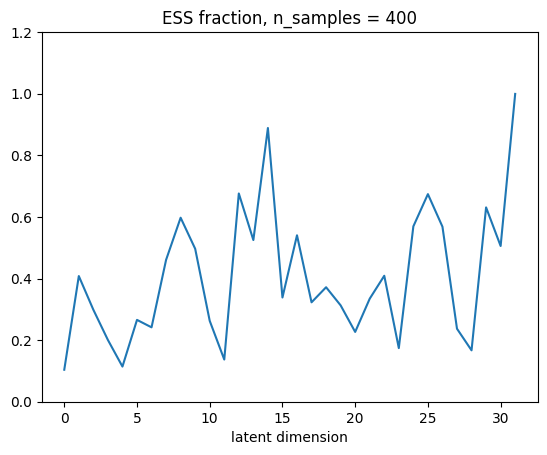

In [40]:
plt.plot((mcmc.diagnostics()['x']['n_eff']).flatten() / (num_samples * num_chains))
plt.title(f"ESS fraction, n_samples = {num_samples * num_chains}")
plt.xlabel("latent dimension")
plt.ylim(0,1.2)

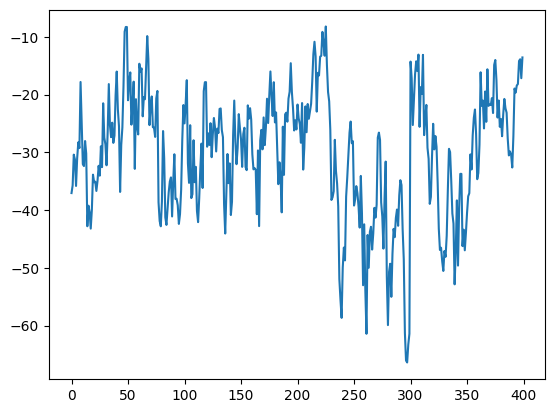

In [41]:
# attenu_samples_hmc_latent = np.load('../testing/attenu_samples_hmc_latent_2026-07-07 11:14:03.081799.npz')['attenu_samples_hmc_latent']
plt.plot(model_nf.log_prob(torch.Tensor(attenu_samples_hmc_latent)).detach().numpy())

Text(0.5, 1.0, 'posterior mean, latent space')

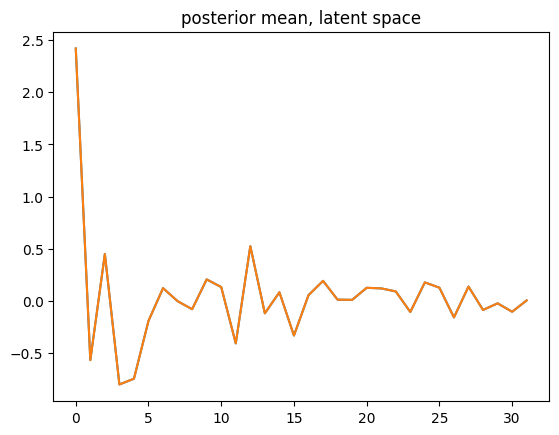

In [42]:
# attenu_samples_hmc_latent = np.load('../testing/attenu_samples_hmc_latent.npz', allow_pickle=True)['arr_0'].tolist()['attenu_samples_hmc_latent']

#attenu_samples_hmc_latent = np.load('../testing/attenu_samples_hmc_latent_2026-07-07 15:08:30.496297.npz')['attenu_samples_hmc_latent']
attenu_samples_hmc_latent_prob = torch.exp(model_nf.log_prob(torch.Tensor(attenu_samples_hmc_latent)))

attenu_samples_hmc_latent = attenu_samples_hmc_latent.detach().numpy()
# attenu_samples_hmc_latent_prob = attenu_samples_hmc_latent_prob / torch.sum(attenu_samples_hmc_latent_prob)
# attenu_samples_hmc_latent_prob = attenu_samples_hmc_latent_prob.detach().numpy()
# attenu_samples_hmc_latent_prob = np.tile(attenu_samples_hmc_latent_prob[:, np.newaxis], (1, attenu_samples_hmc_latent.shape[1]))

attenu_samples_hmc_latent_post_mean = np.mean(attenu_samples_hmc_latent, axis = 0)
attenu_samples_hmc_post_mean = attenu_pca.inverse_transform(attenu_samples_hmc_latent_post_mean.reshape(1, -1)).reshape((256, 256))

attenu_samples_hmc_latent_post_mean = np.mean(attenu_samples_hmc_latent, axis = 0)
plt.plot(attenu_samples_hmc_latent_post_mean)
plt.plot(np.mean(attenu_samples_hmc_latent, axis = 0))
plt.title('posterior mean, latent space')

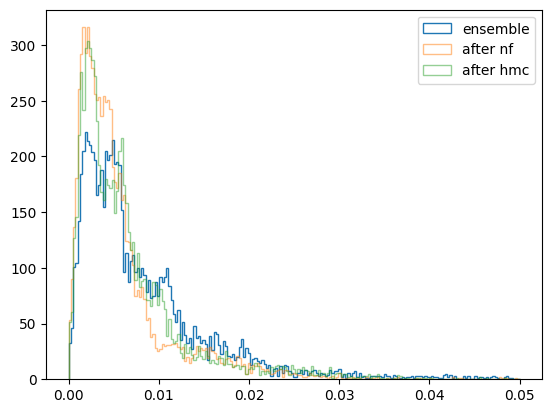

In [43]:
#attenu_samples_hmc_latent = mcmc.get_samples()['x']
#attenu_samples_hmc_latent = attenu_samples_hmc_latent[:, 0, :]
attenu_samples_hmc = attenu_pca.inverse_transform(attenu_samples_hmc_latent)
var_attenu_hmc = np.var(attenu_samples_hmc, axis = 0)
var_attenu_hmc = var_attenu_hmc.reshape((256, 256))

bins = np.linspace(0, 0.05, 200)

plt.hist(var_attenu_ensemble[radar_mask].flatten(), label = 'ensemble', bins = bins, density = False, histtype = 'step')
plt.hist(var_attenu_nf[radar_mask].flatten(), label = 'after nf', alpha = 0.5, bins = bins, density = False, histtype = 'step')
plt.hist(var_attenu_hmc[radar_mask].flatten(), label = 'after hmc', alpha = 0.5, bins = bins, density = False, histtype = 'step')
plt.legend()

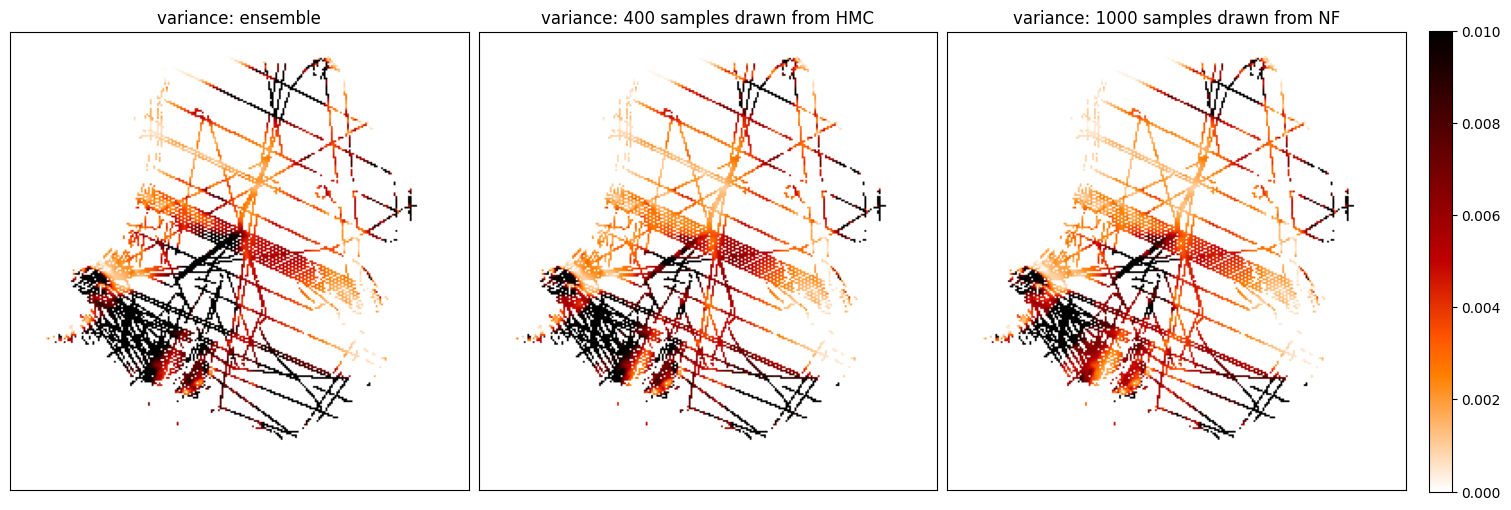

In [98]:
attenu_reconstruct = attenu_pca.inverse_transform(attenu_pca.transform(attenu_fromEm_standard[:, 0, :, :].reshape((-1, attenu_fromEm_standard.shape[2] ** 2))))
attenu_reconstruct_var = np.var(attenu_reconstruct, axis = 0).reshape((256, 256))

# attenu_hmc_samples = attenu_pca.inverse_transform(mcmc.get_samples()['x'][:, 0, :]).reshape((mcmc.get_samples()['x'][:, 0, :].shape[0], 256, 256))
var_attenu_samples_hmc = np.nanvar(attenu_samples_hmc, axis = 0).reshape(256, 256)

fig, ax = plt.subplots(1,3, figsize = (15, 5), layout="constrained")

vmin = 0
vmax = 0.01

im0 = ax[0].imshow(var_attenu_ensemble, vmin = vmin, vmax = vmax, cmap = 'gist_heat_r')
ax[0].set_title(f"variance: ensemble")
ax[0].set_xticks([])
ax[0].set_yticks([])

im1 = ax[1].imshow(var_attenu_hmc, vmin = vmin, vmax = vmax, cmap = 'gist_heat_r')
ax[1].set_title(f"variance: {attenu_samples_hmc.shape[0]} samples drawn from HMC")
ax[1].set_xticks([])
ax[1].set_yticks([])

im2 = ax[2].imshow(var_attenu_nf, vmin = vmin, vmax = vmax, cmap = 'gist_heat_r')
ax[2].set_title(f"variance: {attenu_samples_nf.shape[0]} samples drawn from NF")
ax[2].set_xticks([])
ax[2].set_yticks([])
plt.colorbar(im2)

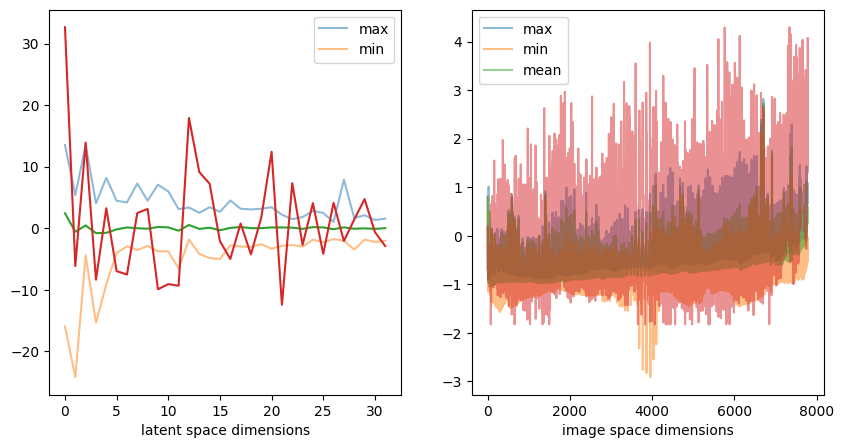

In [46]:
fig, ax = plt.subplots(1, 2, figsize = (10, 5))

attenu_obs_latent = attenu_obs_standard.copy()
attenu_obs_latent[np.isnan(attenu_obs_latent)] = 0
attenu_obs_latent = attenu_pca.transform(attenu_obs_latent.reshape(1, -1))

max_attenu_samples_hmc_latent = np.max(attenu_samples_hmc_latent, axis = 0)
min_attenu_samples_hmc_latent = np.min(attenu_samples_hmc_latent, axis = 0)
ax[0].plot(max_attenu_samples_hmc_latent, alpha = 0.5, label = 'max')
ax[0].plot(min_attenu_samples_hmc_latent, alpha = 0.5, label = 'min')
ax[0].plot(attenu_samples_hmc_latent_post_mean)
ax[0].plot(attenu_obs_latent.flatten())
ax[0].set_xlabel('latent space dimensions')
ax[0].legend()

max_attenu_samples_hmc = np.max(attenu_samples_hmc, axis = 0)
min_attenu_samples_hmc = np.min(attenu_samples_hmc, axis = 0)
ax[1].plot(max_attenu_samples_hmc.reshape(256, 256)[radar_mask], alpha = 0.5, label = 'max')
ax[1].plot(min_attenu_samples_hmc.reshape(256, 256)[radar_mask], alpha = 0.5, label = 'min')
ax[1].plot(attenu_samples_hmc_post_mean[radar_mask], alpha = 0.5, label = 'mean')
ax[1].plot(attenu_obs_standard.reshape(256, 256)[radar_mask].flatten(), alpha = 0.5)
ax[1].set_xlabel('image space dimensions')
ax[1].legend()

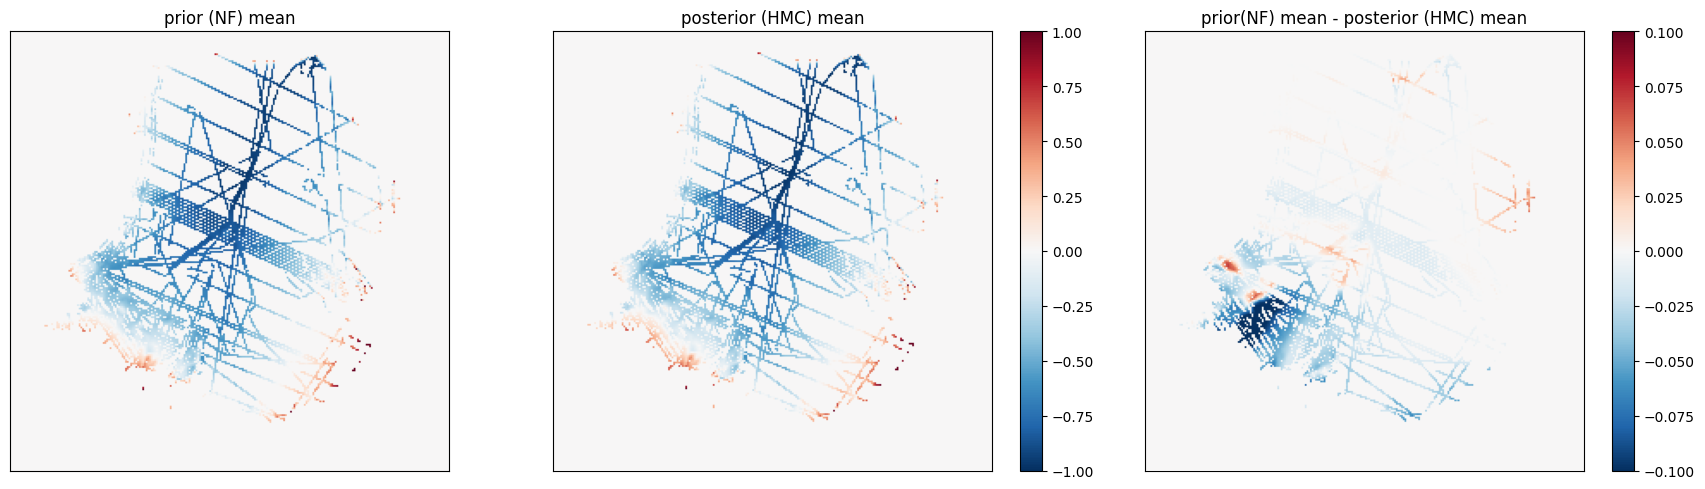

In [96]:
fig, ax = plt.subplots(1, 3, figsize = (18, 5))

vmin = -1
vmax = 1

im0 = ax[0].imshow(np.mean(attenu_samples_nf, axis = 0), vmin = vmin, vmax = vmax, cmap = 'RdBu_r')
ax[0].set_title("prior (NF) mean")
ax[0].set_xticks([])
ax[0].set_yticks([])

im1 = ax[1].imshow(attenu_samples_hmc_post_mean, vmin = vmin, vmax = vmax, cmap = 'RdBu_r')
ax[1].set_title("posterior (HMC) mean")
ax[1].set_xticks([])
ax[1].set_yticks([])
plt.colorbar(im1)

vmin = -0.1
vmax = 0.1
im2 = ax[2].imshow(np.mean(attenu_samples_nf, axis = 0) - attenu_samples_hmc_post_mean, vmin = vmin, vmax = vmax, cmap = 'RdBu_r')
ax[2].set_title("prior(NF) mean - posterior (HMC) mean")
ax[2].set_xticks([])
ax[2].set_yticks([])
plt.colorbar(im2)

fig.tight_layout()

# Validation

#### for training, only keep first 5 componenets, replace remaining components with some constant

#### posterior samples should have no information beyond the 5th component, i.e. remaining dimensions should be filled with that constant

In [85]:
n_components_keep = 5

Text(0.5, 1.0, 'after cutoff')

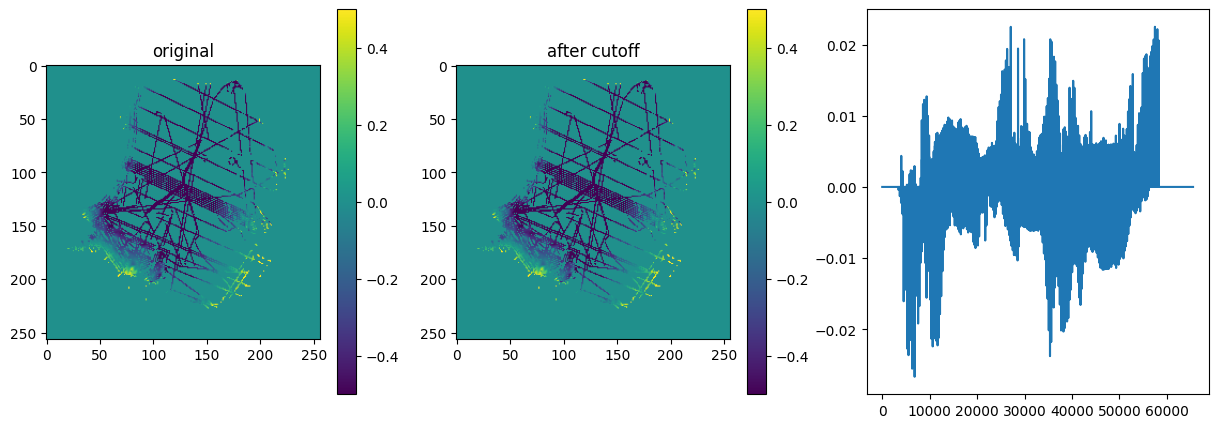

In [86]:
# load data: attenuation rate in PCA latent space
#num_epochs = 50
batch_size = 32

# attenu_fromEm_standard = np.load('attenu_fromEm_standard.npz')['attenu_fromEm_standard']
# attenu_pca = joblib.load('./saved_data/attenu_pca.pkl')
#attenu_pca = sklearn.decomposition.PCA(n_components = 32)
#attenu_pca.fit(attenu_fromEm_standard[:, 0, :, :].reshape((-1, attenu_fromEm_standard.shape[2] ** 2)))
# attenu_pca = joblib.load('../testing/attenu_pca2026-07-06 10:09:51.669799.pkl')
# attenu_latent = attenu_pca.transform(attenu_fromEm_standard[:, 0, :, :].reshape((-1, attenu_fromEm_standard.shape[2] ** 2)))
# attenu_latent = torch.tensor(attenu_latent).float()

attenu_latent_cutoff = attenu_latent.detach().clone()
attenu_latent_cutoff[:, n_components_keep:] = torch.full(attenu_latent[:, n_components_keep:].shape, 0.1)

fig, ax = plt.subplots(1,3, figsize = (15, 5))

vmin = -0.5
vmax = 0.5

attenu_mean_original = np.mean(attenu_pca.inverse_transform(attenu_latent).reshape(attenu_pca.inverse_transform(attenu_latent).shape[0], int(np.sqrt(attenu_pca.inverse_transform(attenu_latent).shape[1])), int(np.sqrt(attenu_pca.inverse_transform(attenu_latent).shape[1]))), axis = 0)
attenu_mean_cutoff = np.mean(attenu_pca.inverse_transform(attenu_latent_cutoff).reshape(attenu_pca.inverse_transform(attenu_latent_cutoff).shape[0], int(np.sqrt(attenu_pca.inverse_transform(attenu_latent_cutoff).shape[1])), int(np.sqrt(attenu_pca.inverse_transform(attenu_latent_cutoff).shape[1]))), axis = 0)

im0 = ax[0].imshow(attenu_mean_original, vmin = vmin, vmax = vmax)
im1 = ax[1].imshow(attenu_mean_cutoff, vmin = vmin, vmax = vmax)
im2 = ax[2].plot(attenu_mean_original.flatten() - attenu_mean_cutoff.flatten())
plt.colorbar(im0)
plt.colorbar(im1)

ax[0].set_title("original")
ax[1].set_title(f"after cutoff")

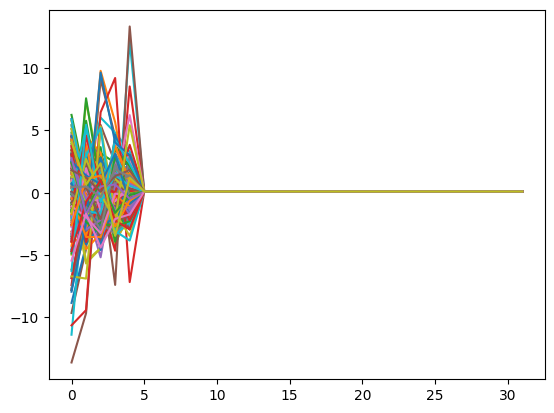

In [87]:
plt.plot(attenu_latent_cutoff.T);

In [88]:
import joblib

# train val test split
attenu_latent_cutoff_dataset = TensorDataset(attenu_latent_cutoff, attenu_latent_cutoff)
#attenu_latent_cutoff_dataset = TensorDataset(attenu_latent_cutoff_standard, attenu_lat/ent_noisy_standard)

train_size = (int(0.7 * len(attenu_latent_cutoff_dataset)) // batch_size) * batch_size
val_size = int((len(attenu_latent_cutoff_dataset) - train_size)/2)
test_size = int(len(attenu_latent_cutoff_dataset) - train_size - val_size)

generator = torch.Generator().manual_seed(42)
attenu_latent_cutoff_train_dataset, attenu_latent_cutoff_val_dataset, attenu_latent_cutoff_test_dataset = random_split(attenu_latent_cutoff_dataset, [train_size, val_size, test_size], generator=generator)

attenu_latent_cutoff_train_dataloader = DataLoader(attenu_latent_cutoff_train_dataset, batch_size = batch_size, shuffle = 1)
attenu_latent_cutoff_val_dataloader = DataLoader(attenu_latent_cutoff_val_dataset, batch_size = batch_size, shuffle = 1)
attenu_latent_cutoff_test_dataloader = DataLoader(attenu_latent_cutoff_test_dataset, batch_size = batch_size, shuffle = 1)

In [89]:
# Set up model_nf
in_features = int(attenu_latent.shape[1]/2)

# Define list of flows
num_layers = 4
flows = []
for i in range(num_layers):
    param_map = nf.nets.MLP([in_features, 64, 256, 64, in_features * 2], init_zeros=True, leaky = 0.01)
    # Add flow layer
    flows.append(nf.flows.AffineCouplingBlock(param_map))
    # Swap dimensions
    flows.append(nf.flows.Permute(in_features * 2, mode='shuffle'))

# base distribution is a Gaussian with num of dimension same as training data
base = nf.distributions.base.DiagGaussian(in_features * 2)

# Construct flow model_nf
model_nf_validation = nf.NormalizingFlow(base, flows)

model_nf_validation

NormalizingFlow(
  (q0): DiagGaussian()
  (flows): ModuleList(
    (0): AffineCouplingBlock(
      (flows): ModuleList(
        (0): Split()
        (1): AffineCoupling(
          (param_map): MLP(
            (net): Sequential(
              (0): Linear(in_features=16, out_features=64, bias=True)
              (1): LeakyReLU(negative_slope=0.01)
              (2): Linear(in_features=64, out_features=256, bias=True)
              (3): LeakyReLU(negative_slope=0.01)
              (4): Linear(in_features=256, out_features=64, bias=True)
              (5): LeakyReLU(negative_slope=0.01)
              (6): Linear(in_features=64, out_features=32, bias=True)
            )
          )
        )
        (2): Merge()
      )
    )
    (1): Permute()
    (2): AffineCouplingBlock(
      (flows): ModuleList(
        (0): Split()
        (1): AffineCoupling(
          (param_map): MLP(
            (net): Sequential(
              (0): Linear(in_features=16, out_features=64, bias=True)
             

In [90]:
# using linear regression to prevent overfitting
window_size = 500

reg = sklearn.linear_model.LinearRegression()
window = np.arange(window_size).reshape(-1, 1)

# Train model_nf_validation
max_epoch = 500
early_stopping_threshold = 1e-3

epoch_loss = np.array([])
epoch_loss_val = np.array([])

#optimizer = torch.optim.Adam(model_nf_validation.parameters(), lr=1e-5, weight_decay=1e-5)
optimizer = torch.optim.AdamW(model_nf_validation.parameters(), lr=1e-5)
model_nf_validation.train()

try:
    for epoch in range(max_epoch):
        optimizer.zero_grad()

        start = torch.Event(enable_timing=True)
        end = torch.Event(enable_timing=True)
        start.record()

        running_loss = 0.0
        running_loss_val = 0.0

        for train_batch, _ in attenu_latent_cutoff_train_dataloader:
            # Compute loss
            loss = model_nf_validation.forward_kld(train_batch)
            
            # Do backprop and optimizer step
            if ~(torch.isnan(loss) | torch.isinf(loss)):
                loss.backward()
                optimizer.step()
                running_loss += loss.item() * train_batch.size(0)

        for val_batch, _ in attenu_latent_cutoff_val_dataloader:
            # Compute loss
            val_loss = model_nf_validation.forward_kld(val_batch)

            # Do backprop and optimizer step
            if ~(torch.isnan(val_loss) | torch.isinf(val_loss)):
                val_loss.backward()
                optimizer.step()
                running_loss_val += val_loss.item() * val_batch.size(0)
                
        epoch_loss = np.append(epoch_loss, running_loss / len(attenu_latent_train_dataloader.dataset))
        epoch_loss_val = np.append(epoch_loss_val, running_loss_val / len(attenu_latent_val_dataloader.dataset))

        if epoch >= window.shape[0]:
            #print(epoch_loss[-window_size:])
            #print(epoch_loss_val[-window_size:])
            reg.fit(window, epoch_loss[-window_size:])
            epoch_loss_slope = reg.coef_


            reg.fit(window, epoch_loss_val[-window_size:])
            epoch_loss_val_slope = reg.coef_
            
            print(f"Epoch validation loss slope: {epoch_loss_val_slope}")
            print(f"Epoch loss slope: {epoch_loss_slope}")

            if (epoch_loss_slope > -early_stopping_threshold) or (epoch_loss_val_slope > -early_stopping_threshold):
                print("Early stopping")
                break

        end.record()
        if torch.cuda.is_available():
            torch.cuda.synchronize()
        print(f"Epoch [{epoch + 1}/{max_epoch}], loss: {epoch_loss[epoch]:.4f}, validation loss: {epoch_loss_val[epoch]:.4f}, time elapsed = {start.elapsed_time(end)/1000:.2f} s")
        
    torch.save(model_nf_validation.state_dict(), f'./saved_data/validation_realNVP.pth')
    np.savez(f'./saved_data/validation_realNVP_loss.npz',epoch_loss = epoch_loss, epoch_loss_val = epoch_loss_val) 

except KeyboardInterrupt:
    torch.save(model_nf_validation.state_dict(), f'./saved_data/validation_realNVP.pth')
    np.savez(f'./saved_data/validation_realNVP_loss.npz',epoch_loss = epoch_loss, epoch_loss_val = epoch_loss_val)


Epoch [1/500], loss: 43.8565, validation loss: 53.9286, time elapsed = 0.01 s
Epoch [2/500], loss: 43.8273, validation loss: 53.9009, time elapsed = 0.01 s
Epoch [3/500], loss: 43.7987, validation loss: 53.8729, time elapsed = 0.01 s
Epoch [4/500], loss: 43.7691, validation loss: 53.8430, time elapsed = 0.01 s
Epoch [5/500], loss: 43.7375, validation loss: 53.8129, time elapsed = 0.01 s
Epoch [6/500], loss: 43.7061, validation loss: 53.7811, time elapsed = 0.01 s
Epoch [7/500], loss: 43.6708, validation loss: 53.7481, time elapsed = 0.01 s
Epoch [8/500], loss: 43.6338, validation loss: 53.7129, time elapsed = 0.01 s
Epoch [9/500], loss: 43.5968, validation loss: 53.6769, time elapsed = 0.01 s
Epoch [10/500], loss: 43.5568, validation loss: 53.6384, time elapsed = 0.01 s
Epoch [11/500], loss: 43.5145, validation loss: 53.5984, time elapsed = 0.01 s
Epoch [12/500], loss: 43.4704, validation loss: 53.5566, time elapsed = 0.01 s
Epoch [13/500], loss: 43.4230, validation loss: 53.5116, time

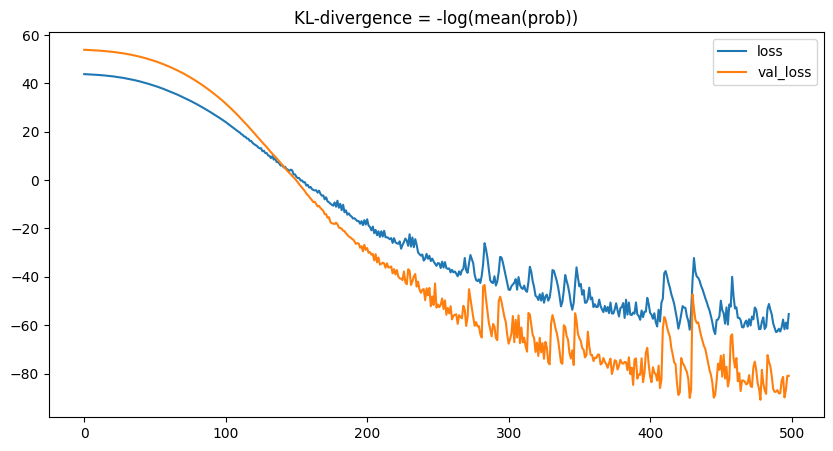

In [91]:
# Plot loss
#epoch_loss = np.load('../testing/realNVP_2026-06-22 15:29:54.090759_loss.npz')['epoch_loss']
#epoch_loss_val = np.load('../testing/realNVP_2026-06-22 15:29:54.090759_loss.npz')['epoch_loss_val']

plt.figure(figsize=(10, 5))
plt.plot(epoch_loss[0:-1], label='loss')
plt.plot(epoch_loss_val[0:-1], label='val_loss')

# plt.yscale("log")

plt.title('KL-divergence = -log(mean(prob))')
plt.legend()
plt.show()


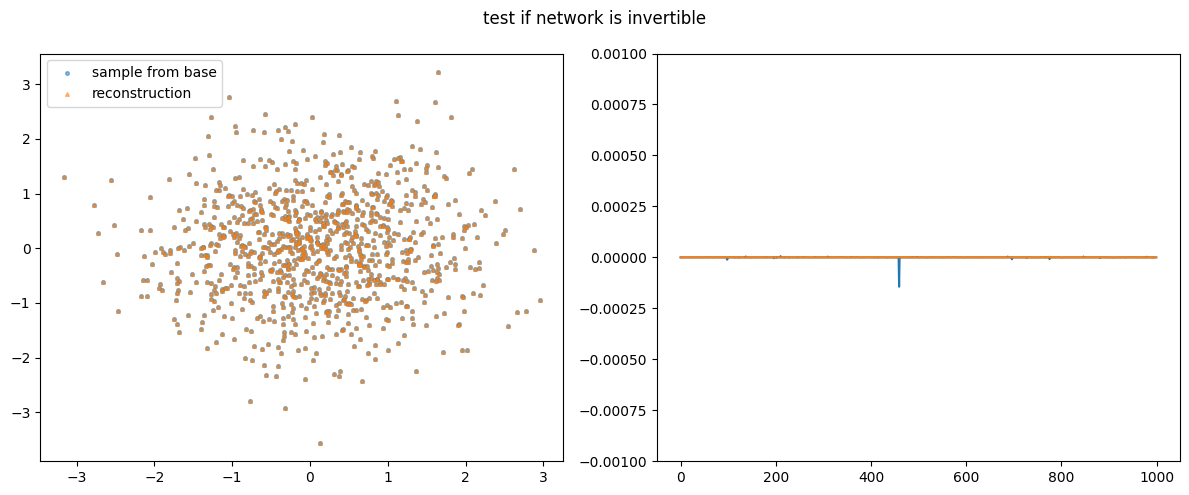

In [92]:
# model_nf_validation.load_state_dict(torch.load('../notebooks/saved_data/realNVP_32_5e-05_128_64_2.pth', weights_only=True))
model_nf_validation.eval()

x0 = base.sample(1000)
x1_from_x0 = model_nf_validation.forward(x0)
x1 = model_nf_validation.sample(1000)[0]
x0_from_x1_from_x0 = model_nf_validation.inverse(x1_from_x0)

x0 = x0.detach().numpy()
x1 = x1.detach().numpy()
x1_from_x0 = x1_from_x0.detach().numpy()
x0_from_x1_from_x0 = x0_from_x1_from_x0.detach().numpy()

fig, ax = plt.subplots(1, 2, figsize = (12, 5))
ax[0].scatter(x0[:, 0], x0[:, 1], alpha = 0.5, label = 'sample from base', s = 7)
#plt.scatter(x1[:, 0], x1[:, 1])
#plt.scatter(x1_from_x0[:, 0], x1_from_x0[:, 1])
ax[0].scatter(x0_from_x1_from_x0[:, 0], x0_from_x1_from_x0[:, 1], alpha = 0.5, label = 'reconstruction', marker = '^', s = 7)
ax[0].legend()


ax[1].plot(x0_from_x1_from_x0[:, 0] - x0[:, 0])
ax[1].plot(x0_from_x1_from_x0[:, 1] - x0[:, 1])
ax[1].set_ylim(-1e-3, 1e-3)

fig.suptitle("test if network is invertible")
fig.tight_layout()

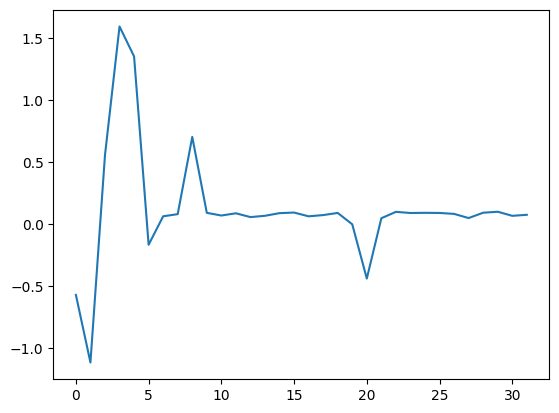

In [93]:
plt.plot(torch.mean(attenu_samples_nf_latent, axis = 0).detach().numpy())

Text(0.5, 1.0, 'diff (every pixel)')

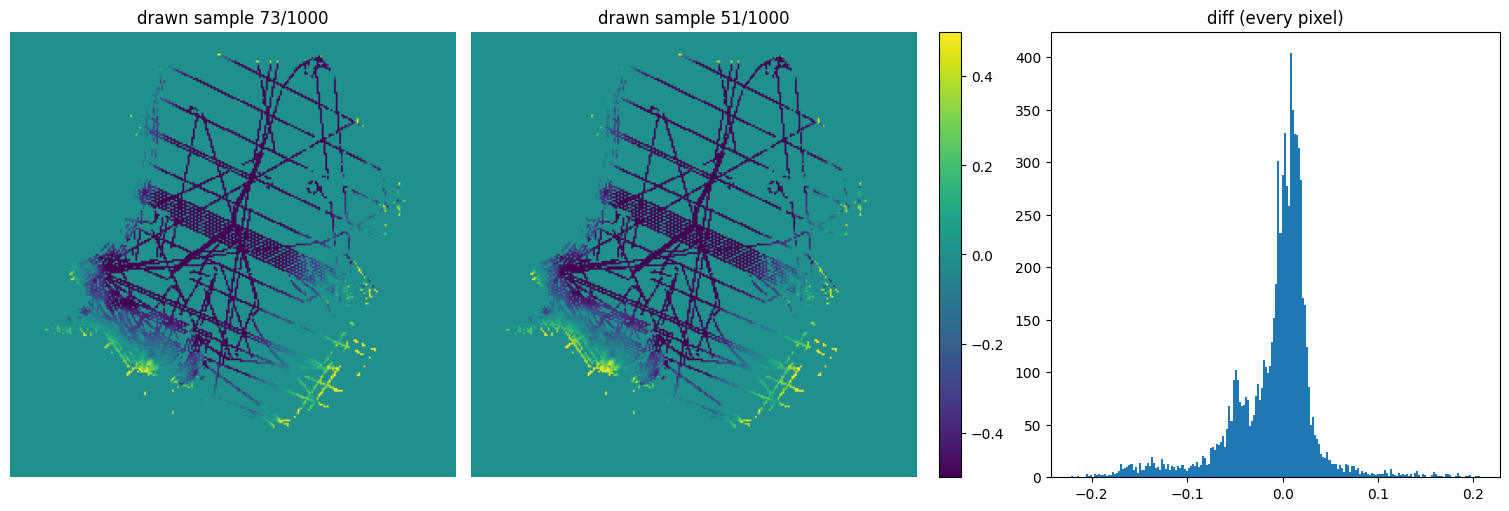

In [94]:
#attenu_pca = joblib.load('../testing/attenu_pca2026-06-12 15:13:52.857122.pkl')

attenu_samples_nf_latent, attenu_samples_log_prob = model_nf_validation.sample(1000)
attenu_samples_nf_latent = attenu_samples_nf_latent.reshape((attenu_samples_nf_latent.shape[0], -1))
attenu_samples_nf_latent = attenu_samples_nf_latent[(~torch.isnan(attenu_samples_log_prob)) & (~torch.isinf(attenu_samples_log_prob)), :]
attenu_samples_nf_latent[attenu_samples_nf_latent == torch.nan] = 0
attenu_samples_nf_latent[attenu_samples_nf_latent == torch.inf] = 0
attenu_samples_nf_latent[attenu_samples_nf_latent == -torch.inf] = 0
attenu_samples_nf_latent[torch.abs(attenu_samples_nf_latent) > 1e2] = 0
attenu_samples_nf = attenu_pca.inverse_transform(attenu_samples_nf_latent.detach().numpy())
attenu_samples_nf = attenu_samples_nf.reshape((attenu_samples_nf_latent.shape[0], 256, 256))

figs, axs = plt.subplots(1,3, figsize = (15, 5), layout="constrained")

vmin = -0.5
vmax = 0.5

rng = np.random.default_rng()
idx = rng.choice(attenu_samples_nf.shape[0], size=2, replace=False)

axs[0].imshow(attenu_samples_nf[idx[0], :, :], vmin = vmin, vmax = vmax)
axs[0].set_title(f"drawn sample {idx[0]}/{attenu_samples_nf.shape[0]}")
axs[0].set_axis_off()

im1 = axs[1].imshow(attenu_samples_nf[idx[1], :, :], vmin = vmin, vmax = vmax)
axs[1].set_title(f"drawn sample {idx[1]}/{attenu_samples_nf.shape[0]}")
axs[1].set_axis_off()
plt.colorbar(im1)

axs[2].hist((attenu_samples_nf[idx[0], :, :] - attenu_samples_nf[idx[1], :, :])[radar_mask].flatten(), bins = 200)
axs[2].set_title("diff (every pixel)")
# axs[2].xaxis.set_visible(False)

Warmup:  12%|█▏        | 244/2000 [21:19,  5.24s/it, step size=4.44e-03, acc. prob=0.773]


Text(0.5, 1.0, 'diff (flattened)')

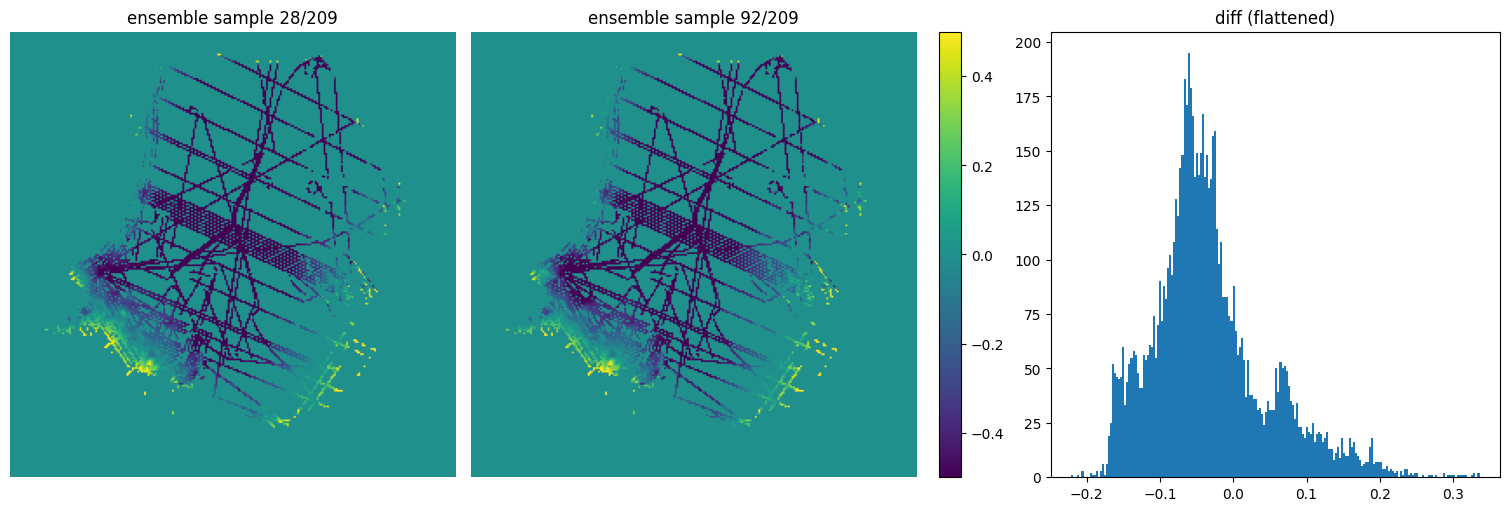

In [95]:
# ensemble samples

attenu_samples_ensemble = attenu_pca.inverse_transform(attenu_latent.detach().numpy().reshape(attenu_latent.shape[0], -1))
attenu_samples_ensemble = attenu_samples_ensemble.reshape((attenu_samples_ensemble.shape[0], 256, 256))
figs, axs = plt.subplots(1,3, figsize = (15, 5), layout="constrained")

vmin = -0.5
vmax = 0.5

rng = np.random.default_rng()
idx = rng.choice(attenu_samples_ensemble.shape[0], size=2, replace=False)

axs[0].imshow(attenu_samples_ensemble[idx[0], :, :], vmin = vmin, vmax = vmax)
axs[0].set_title(f"ensemble sample {idx[0]}/{attenu_samples_ensemble.shape[0]}")
axs[0].set_axis_off()

im1 = axs[1].imshow(attenu_samples_ensemble[idx[1], :, :], vmin = vmin, vmax = vmax)
axs[1].set_title(f"ensemble sample {idx[1]}/{attenu_samples_ensemble.shape[0]}")
axs[1].set_axis_off()
plt.colorbar(im1)

axs[2].hist((attenu_samples_ensemble[idx[0], :, :] - attenu_samples_ensemble[idx[1], :, :])[radar_mask].flatten(), bins = 200)
axs[2].set_title("diff (flattened)")

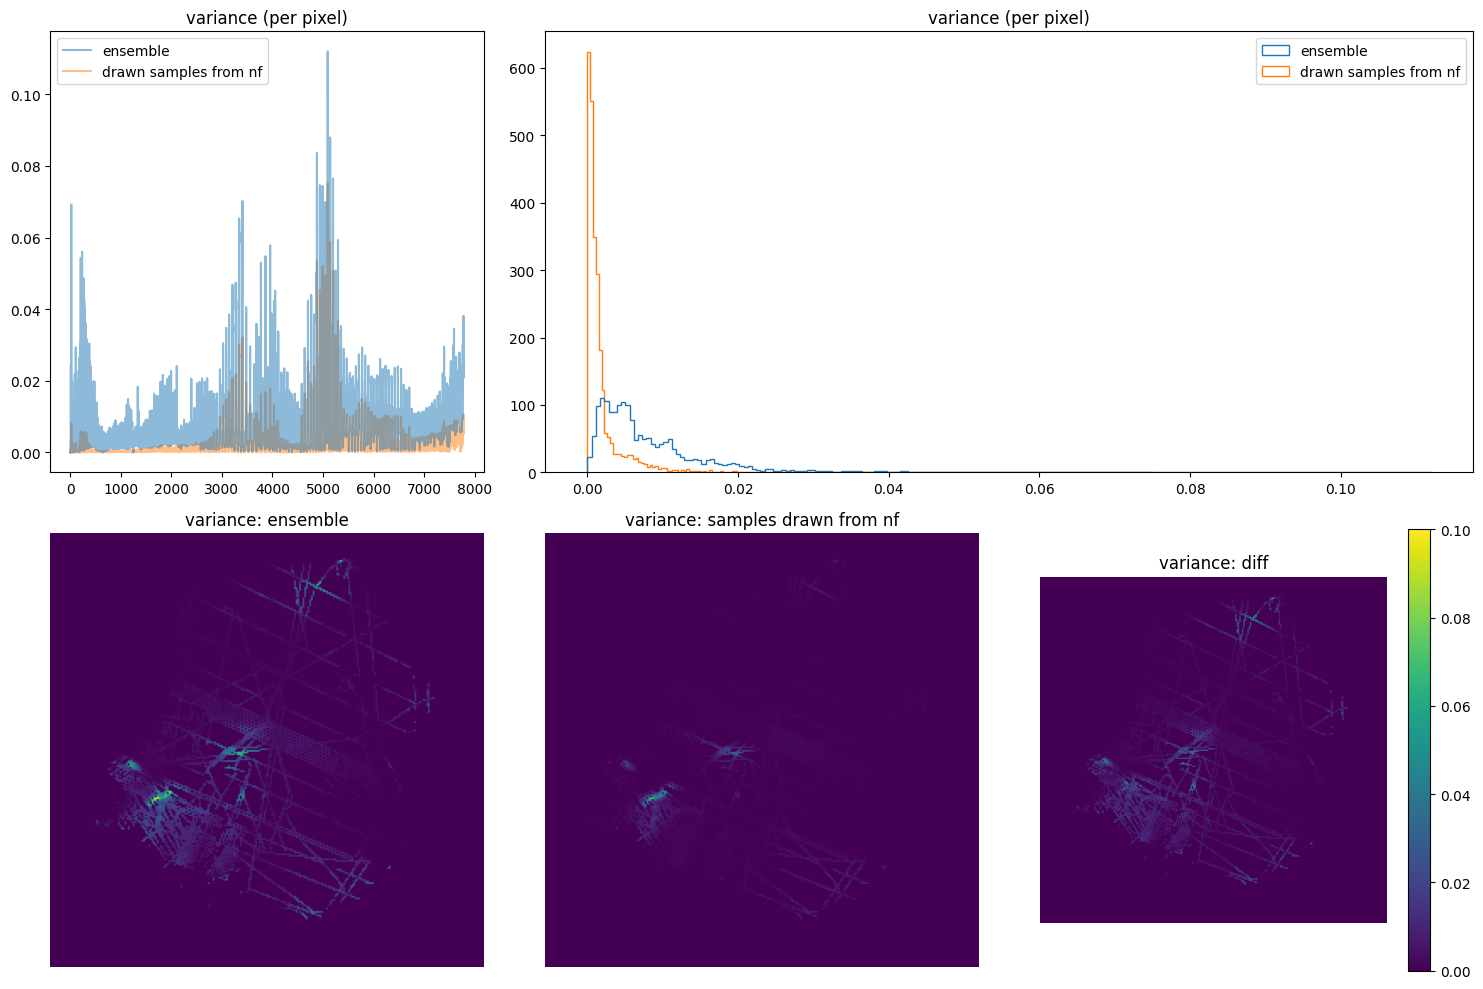

In [96]:
fig, ax = plt.subplot_mosaic([['A', 'B', 'B'],
                              ['C', 'D', 'E']],
                             figsize = (15, 10))

var_attenu_ensemble = np.var(attenu_samples_ensemble, axis = 0)
var_attenu_nf = np.var(attenu_samples_nf, axis = 0)
ax['A'].plot(var_attenu_ensemble[radar_mask].flatten(), label = 'ensemble', alpha = 0.5, zorder = 3)
ax['A'].plot(var_attenu_nf[radar_mask].flatten(), label = 'drawn samples from nf', alpha = 0.5)
ax['A'].set_title("variance (per pixel)")
ax['A'].legend()

bins = np.arange(0, 1, 0.05)
ax['B'].hist(var_attenu_ensemble[radar_mask].flatten(), label = 'ensemble', zorder = 3, bins = 200, density = True, histtype='step')
ax['B'].hist(var_attenu_nf[radar_mask].flatten(), label = 'drawn samples from nf', bins = 200, density = True, histtype='step')
ax['B'].set_title("variance (per pixel)")
ax['B'].legend()

vmin = 0
vmax = 0.1

im0 = ax['C'].imshow(var_attenu_ensemble, vmin = vmin, vmax = vmax)
ax['C'].set_title(f"variance: ensemble")
ax['C'].set_axis_off()

im1 = ax['D'].imshow(var_attenu_nf, vmin = vmin, vmax = vmax)
ax['D'].set_title(f"variance: samples drawn from nf")
ax['D'].set_axis_off()

im2 = ax['E'].imshow(var_attenu_ensemble - var_attenu_nf, vmin = vmin, vmax = vmax)
ax['E'].set_title(f"variance: diff")
ax['E'].set_axis_off()
plt.colorbar(im2)

fig.tight_layout()

In [97]:
import pyro
from pyro.infer.mcmc import MCMC, HMC, NUTS
import hamiltonianMC_nf

custom_potential = hamiltonianMC_nf.custom_potential(model_nf_validation, attenu_pca, attenu_obs_standard, verbose = False)

log_posterior_complied = torch.compile(custom_potential.log_posterior)

mcmc_kernel = NUTS(potential_fn = custom_potential.log_posterior)

mcmc = MCMC(mcmc_kernel, num_samples=100, warmup_steps=100, initial_params={"x": model_nf_validation.sample(1)[0].detach()})
mcmc.run()
# attenu_samples_hmc_latent[i, :] = mcmc.get_samples()['x'][0][0]

attenu_samples_validation_hmc_latent = mcmc.get_samples()['x']
attenu_samples_validation_hmc_latent = attenu_samples_validation_hmc_latent[:, 0, :]
torch.save(attenu_samples_validation_hmc_latent, './saved_data/attenu_samples_validation_hmc_latent.pt')

Sample: 100%|██████████| 200/200 [01:46,  1.88it/s, step size=4.07e-02, acc. prob=0.673]


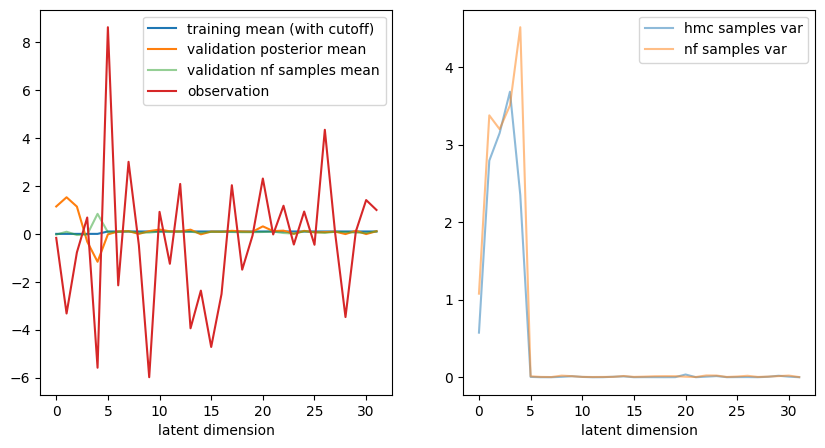

In [98]:
fig, ax = plt.subplots(1, 2, figsize = (10, 5))

#attenu_samples_hmc_latent = np.load("../testing/validation_attenu_samples_hmc_latent_2026-07-07 11:14:29.910122.npz")['attenu_samples_hmc_latent']
attenu_samples_validation_hmc_latent_mean = torch.mean(attenu_samples_validation_hmc_latent, axis = 0)
attenu_latent_cutoff_mean = torch.mean(attenu_latent_cutoff, axis = 0)

ax[0].plot(attenu_latent_cutoff_mean, label = 'training mean (with cutoff)')
ax[0].plot(attenu_samples_validation_hmc_latent_mean, label = 'validation posterior mean')
ax[0].plot(torch.mean(attenu_samples_nf_latent, axis = 0).detach().numpy(), label = 'validation nf samples mean', alpha = 0.5)
ax[0].plot(attenu_obs_samples_mean_latent.flatten(), label = 'observation')

# plt.title('note: training mean at 0 because PCA centers data')

ax[0].set_xlabel('latent dimension')

ax[1].plot(torch.var(attenu_samples_validation_hmc_latent, axis = 0).detach().numpy(), label = 'hmc samples var', alpha = 0.5)
ax[1].plot(torch.var(attenu_samples_nf_latent, axis = 0).detach().numpy(), label = 'nf samples var', alpha = 0.5)
# plt.title('note: training mean at 0 because PCA centers data')

ax[1].set_xlabel('latent dimension')

ax[0].legend()
ax[1].legend()

# Archive

## Architecture (glow)

In [46]:
# # Define flows
# L = 3
# K = 16
# torch.manual_seed(0)

# input_shape = (1, 8, 8)
# channels = 1
# hidden_channels = 32
# split_mode = 'channel'
# scale = True
# num_classes = 10

# # Set up flows, distributions and merge operations
# q0 = []
# merges = []
# flows = []
# for i in range(L):
#     flows_ = []
#     for j in range(K):
#         flows_ += [nf.flows.GlowBlock(channels * 2 ** (L + 1 - i), hidden_channels,
#                                      split_mode=split_mode, scale=scale)]
#     flows_ += [nf.flows.Squeeze()]
#     flows += [flows_]
#     if i > 0:
#         merges += [nf.flows.Merge()]
#         latent_shape = (input_shape[0] * 2 ** (L - i), input_shape[1] // 2 ** (L - i), 
#                         input_shape[2] // 2 ** (L - i))
#     else:
#         latent_shape = (input_shape[0] * 2 ** (L + 1), input_shape[1] // 2 ** L, 
#                         input_shape[2] // 2 ** L)
    
#     #q0 += [nf.distributions.ClassCondDiagGaussian(latent_shape, num_classes)]
#     print(latent_shape)
#     q0 += [nf.distributions.base.DiagGaussian(latent_shape)]

# # Construct flow model with the multiscale architecture
# model_nf = nf.MultiscaleFlow(q0, flows, merges)